In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

import pandas as pd

import astropy
import astropy.table as at
import matplotlib.cm as cm


from astropy.io.votable import parse, parse_single_table

from astropy.coordinates import SkyCoord
from dustmaps.planck import PlanckQuery
from dustmaps.sfd import SFDQuery

import astropy.units as units
import sklearn

import time
#from astroquery.gaia import Gaia
import os
from astropy.io import fits

# from astroquery.skyview import SkyView
# from astroquery.simbad import Simbad
import astropy.coordinates as coord
# import lightkurve as lk
import scipy
from scipy import integrate
#from gaiaxpy.plotter.multi_absolute import MultiAbsolutePlotter

import glob

# import multiprocessing as mp
# mp.set_start_method(None, force=True)

# from astroARIADNE.star import Star
# from astropy.modeling.models import BlackBody
# from astropy import units as u
# from astropy.visualization import quantity_support
# from astroARIADNE.star import Star
# from astroARIADNE.fitter import Fitter
# from astroARIADNE.plotter import SEDPlotter
# import pickle as pkl
# from extinction import apply
# from isochrones.interp import DFInterpolator
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
#from PyAstronomy import pyasl
from scipy.optimize import curve_fit

#from astroARIADNE.phot_utils import *
from scipy import integrate

from matplotlib.lines import Line2D
import matplotlib
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.neighbors import NearestNeighbors, BallTree

from astroquery.simbad import Simbad

# from gaiaxpy.plotter.multi_xp import MultiXpPlotter
# from gaiaxpy import plot_spectra
# from gaiaxpy.core.satellite import BANDS

# from gaiaxpy import convert, calibrate

In [20]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

import pyvo

def get_ang_sep_gaia(ra_t, dec_t):
    q_order_ang = "SELECT *, DISTANCE("
    q_order_ang += f"POINT({ra_t},{dec_t}), "
    q_order_ang += "POINT(ra, dec)) AS ang_sep "
    q_order_ang += "FROM gaiadr3.gaia_source_lite "
    q_order_ang += "WHERE 1 = CONTAINS("
    q_order_ang += f"POINT({ra_t},{dec_t}), "
    q_order_ang += "CIRCLE(ra, dec, 10./3600.)) "
    # Do we want to keep the parallax condition ?
    #q_order_ang += "AND parallax IS NOT NULL"
    q_order_ang += "ORDER BY ang_sep ASC"
    return q_order_ang
def get_ang_sep_tmass(ra_t, dec_t):
    q_order_ang = "SELECT *, DISTANCE("
    q_order_ang += f"POINT({ra_t},{dec_t}), "
    q_order_ang += "POINT(ra, dec)) AS ang_sep "
    q_order_ang += "FROM gaiadr1.tmass_original_valid "
    q_order_ang += "WHERE 1 = CONTAINS("
    q_order_ang += f"POINT({ra_t},{dec_t}), "
    q_order_ang += "CIRCLE(ra, dec, 10./3600.)) "
    # Do we want to keep the parallax condition ?
    #q_order_ang += "AND parallax IS NOT NULL"
    q_order_ang += "ORDER BY ang_sep ASC"
    return q_order_ang

def get_timeseries_wise(ra_t, dec_t):
    service = pyvo.dal.TAPService('https://irsa.ipac.caltech.edu/TAP')
    query = "SELECT source_id_mf,ra,dec,nb,na,cc_flags,frame_id,mjd,w1mpro_ep,w1sigmpro_ep,w1rchi2_ep,w2mpro_ep"
    query += ",w2sigmpro_ep,w2rchi2_ep,w3mpro_ep,w3sigmpro_ep,w3rchi2_ep,w4mpro_ep,w4sigmpro_ep,w4rchi2_ep,"
    query += " w1flux_ep,w1sigflux_ep,w2flux_ep,w2sigflux_ep,w3flux_ep,w3sigflux_ep,w4flux_ep,w4sigflux_ep,"
    query += "qi_fact,saa_sep,moon_masked FROM allwise_p3as_mep WHERE "
    query += f" CONTAINS(POINT('ICRS',ra, dec),CIRCLE('ICRS', {ra_t}, {dec_t}, 0.00249))=1"
    result = service.run_async(query)
    tab = result.to_table()
    return tab



def get_timeseries_neowise(ra_t, dec_t, ang=0.00249):
    
    service = pyvo.dal.TAPService('https://irsa.ipac.caltech.edu/TAP')
    query = "SELECT ra,dec,sigra,sigdec,sigradec,w1mpro,w1sigmpro,w1snr,w1rchi2,w2mpro,w2sigmpro,w2snr,w2rchi2,"
    query += "nb,na,cc_flags,ph_qual,qual_frame,mjd,w1flux,w1sigflux,w2flux,w2sigflux,allwise_cntr,w1mpro_allwise,"
    query += "w1sigmpro_allwise,w2mpro_allwise,w2sigmpro_allwise,w3mpro_allwise,w3sigmpro_allwise,"
    query += "w4mpro_allwise,w4sigmpro_allwise,tmass_key,j_m_2mass,j_msig_2mass,h_m_2mass,h_msig_2mass,k_m_2mass"
    query += ",k_msig_2mass FROM neowiser_p1bs_psd WHERE "
    query += f" CONTAINS(POINT('ICRS', ra, dec),CIRCLE('ICRS',{ra_t}, {dec_t}, {ang}))=1"
    result = service.run_async(query)
    tab = result.to_table()
    return tab

def get_ang_sep_unwise(ra_t, dec_t):
    service = pyvo.dal.TAPService('https://irsa.ipac.caltech.edu/TAP')
    query = "SELECT unwise_objid,ra,dec FROM unwise_2019 WHERE "
    query += f" CONTAINS(POINT('ICRS', ra, dec),CIRCLE('ICRS',{ra_t}, {dec_t}, 10/3600))=1"
    result = service.run_async(query)
    tab = result.to_table()
    return tab


def get_allwise_neighbscore(sc_id, allwise_id):
    q_order_ang = "SELECT * "
    q_order_ang += "FROM gaiadr3.allwise_neighbourhood WHERE "
    q_order_ang += f"source_id={sc_id} AND allwise_oid={allwise_id}"
    return q_order_ang


def get_catwise_pmSNR(ra_t,dec_t):
    
### Get SNR AND Pmra pmdec from CATWise
# SELECT source_name,source_id,ra,dec,sigra,sigdec,w1snr,w2snr,w3snr,w4snr, w1mpro,w1sigmpro,w2mpro,w2sigmpro,rchi2,nb,
#        w1nm,w1m,w2nm,w2m,meanobsmjd,pmra,pmdec,sigpmra,sigpmdec,rchi2_pm,cc_flags,ab_flags 
# FROM catwise_2020 
# WHERE CONTAINS(POINT('ICRS', ra, dec),CIRCLE('ICRS', 89.860361, -9.3650726, 0.002777777777777778))=1
    service = pyvo.dal.TAPService('https://irsa.ipac.caltech.edu/TAP')
    query = "SELECT source_name,source_id,ra,dec,sigra,sigdec,w1snr,w2snr,w1mpro,w1sigmpro,"
    query += "w2mpro,w2sigmpro,rchi2,nb, w1nm,w1m,w2nm,w2m,meanobsmjd,pmra,pmdec,sigpmra,sigpmdec,rchi2_pm,"
    query += "cc_flags,ab_flags FROM catwise_2020 "
    query += f"WHERE CONTAINS(POINT('ICRS', ra, dec),CIRCLE('ICRS', {ra_t}, {dec_t}, 0.0001))=1"
    #print(query)

    result = service.run_async(query)
    tab = result.to_table()
    
    return tab


# This could be more elegant.... (all expect df_un)


#  run the following to get data for ang sep crowding cut 



def get_ang_sep_crowding(idc_candidates, df_un, ang_sep_thresh_gaia = 0.0025):


    for i in idc_candidates: #addit_candi_hat: #idc_candidates:

        print("------------------")
        print(f"Gaia DR3 {df_un['source_id'].iloc[i]}")
        ra_t, dec_t = df_un['ra_2'].iloc[i], df_un['dec_2'].iloc[i]
        print(f"ra: {ra_t}   dec: {dec_t}")
        print(f"https://www.legacysurvey.org/viewer-dev?ra={ra_t}&dec={dec_t}&layer=unwise-neo7&zoom=15")
        print(f"https://www.legacysurvey.org/viewer-dev?ra={ra_t}&dec={dec_t}&layer=unwise-w3w4&zoom=15")


        query_ = get_ang_sep_gaia(ra_t, dec_t)
        print(query_)
        flag_query = True
        tryout=1
        while (flag_query & (tryout<12)):
            try:
                job = Gaia.launch_job_async(query_)
                flag_query = False
            except:
                print(f"Retrying gaia query for the {tryout} time")
                tryout+=1
                
        r = job.get_results().to_pandas()
        print(len(r))
        #print(r)
        if len(r) > 1:
            #dits_angulradec.append(np.min(r['ang_sep'].values[1:]))
            # There is more than one in the query:
            #if r['ang_sep'].values[1] > ang_sep_thresh_gaia
            df_un.loc[i, 'angsep_crowding_gaia'] = r['ang_sep'].values[1]
            print("more than 1 in search for Gaia")
            print(df_un['angsep_crowding_gaia'].iloc[i])
    #     else:
    #         dits_angulradec.append(10000)

        #print(r[['SOURCE_ID', 'parallax', 'phot_g_mean_mag','ang_sep']])


        query_ = get_ang_sep_tmass(ra_t, dec_t)
        print(query_)
        flag_query = True
        tryout=1
        while (flag_query & (tryout<12)):
            try:
                job = Gaia.launch_job_async(query_)
                flag_query = False
            except:
                print(f"Retrying gaia query for the {tryout} time")
                tryout+=1

        r = job.get_results().to_pandas()
        print(len(r))
        if len(r) > 1:
            #dits_angulradec.append(np.min(r['ang_sep'].values[1:]))
            # There is more than one in the query:
            #if r['ang_sep'].values[1] > ang_sep_thresh_gaia
            df_un.loc[i, 'angsep_crowding_tmass'] = r['ang_sep'].values[1]
            print("more than 1 in search for 2MASS")
            print(df_un['angsep_crowding_tmass'].iloc[i])
    #     else:
    #         dits_angulradec.append(10000)

        #print(r[['DESIGNATION', 'ra','dec','ang_sep']])



        r = get_ang_sep_unwise(ra_t, dec_t)
        c1 = SkyCoord(ra=ra_t*u.degree, dec=dec_t*u.degree, frame='icrs')
    #     c2 = SkyCoord(ra=11*u.degree, dec=10*u.degree, frame='fk5')
    #     c1.separation(c2)
        print(len(r))
        if len(r) > 1:
            #dits_angulradec.append(np.min(r['ang_sep'].values[1:]))
            # There is more than one in the query:
            #if r['ang_sep'].values[1] > ang_sep_thresh_gaia
            ang_dist = []
            for j in range(len(r)):
                c2 = SkyCoord(ra=r['ra'][j]*u.degree, dec=r['dec'][j]*u.degree, frame='icrs')
                ang_dist.append(c1.separation(c2).value)
            second_min_sep = np.sort(np.array(ang_dist))[1]
            df_un.loc[i, 'angsep_crowding_unwise'] = second_min_sep
            print("Ang dist in unwise when more than 1 candidate")
            print(ang_dist)
            print("more than 1 in search for UnWise")
            print(df_un['angsep_crowding_unwise'].iloc[i])
    #     else:
    #         dits_angulradec.append(10000)

        #print(r[['source_id', 'parallax', 'phot_g_mean_mag','ang_sep']])
        #print(r['unwise_objid','ra','dec'])

        del ra_t, dec_t



        print("---")


#run the following to grab the data for the FoM Score, and PMRA-PMDEC from CatWise


def get_FOM_and_catwise(idc_candidates, df_un):

    for i in idc_candidates: #addit_candi_hat :#idc_candidates:

        print("------------------")
        print(f"Gaia DR3 {df_un['source_id'].iloc[i]}")
        ra_t, dec_t = df_un['ra_2'].iloc[i], df_un['dec_2'].iloc[i]


        sc_id = df_un['source_id'].iloc[i]
        allwise_id = df_un['allwise_oid'].iloc[i]

        query_ = get_allwise_neighbscore(sc_id, allwise_id)
        #print(query_)
        #print(query_)
        job = Gaia.launch_job_async(query_)

        r = job.get_results().to_pandas()
        df_un.loc[i, 'score_FOM'] =r['score'][0]
        #

        r = get_catwise_pmSNR(ra_t, dec_t)
        #print(f"Lenght of query {len(r)}")

        if (len(r)>1) | (len(r)==0):
            print("!!! Some issues there / remove this outlier? More than 1 match within radius")
    #         snrw1.append(0)
    #         snrw2.append(0)
    #         pmracat.append(0)
    #         pmdeccat.append(0)
    #         mask_issue.append(False)
        else:
            df_un.loc[i,'snrw1'] = r['w1snr']
            df_un.loc[i, 'snrw2'] = r['w2snr']
            df_un.loc[i,'pmracat'] = r['pmra']
            df_un.loc[i,'pmdeccat'] = r['pmdec']
        #mask_issue.append(True)
        del r
        
        
## Compute Simbad properties 

def get_simbad(idcs_maskplot, df_un):
    customSimbad = Simbad()
    customSimbad.add_votable_fields('morphtype', 'mt', 'otype', 'otypes', 'rot', 
                                    'sp', 'sptype', 'diameter', 'dim')



    results_simbad = []
    two_res_simbad = []
    for i in range(len(idcs_maskplot)):
        result_table = customSimbad.query_region(coord.SkyCoord(ra=df_un['ra_2'].iloc[idcs_maskplot[i]],
                                                      dec=df_un['dec_2'].iloc[idcs_maskplot[i]],
                                       unit=(u.deg, u.deg), frame='icrs'),
                                       radius=0.001 * u.deg)
        results_simbad.append(result_table)

        print("------------")
        print(f"Gaia {df_un['source_id'].iloc[idcs_maskplot[i]]}")
        if result_table is None:
            print("No match in Simbad")
        else:
            print(len(result_table))
            if len(result_table)>1:
                two_res_simbad.append(idcs_maskplot[i])
                result_table = result_table[0]
                df_un.loc[idcs_maskplot[i], 'simbad_other_objects'] = 'More than 1'
                print("DEAL WITH THIS")
            elif len(result_table)==0:
                print("No match in Simbad")
            else:
                try:
                    #print(result_table)
                    print(result_table['OTYPE'])
                    print(result_table['OTYPES'])
                    print(result_table['SP_TYPE'])
                    print(result_table['SP_TYPE_2'])
    
                    ## Check the actual angular sep with target
                    c1 = coord.SkyCoord(ra=df_un['ra_2'].iloc[idcs_maskplot[i]],
                                       dec=df_un['dec_2'].iloc[idcs_maskplot[i]],
                                               unit=(u.deg, u.deg), frame='icrs')
                    c2 = SkyCoord(ra=result_table['RA'][0], dec=result_table['DEC'][0],unit=(u.hourangle, u.deg), 
                                  frame='icrs')
                    dist = c1.separation(c2).value
                    print(f"Distance {dist}")
                    print(df_un['ra_2'].iloc[idcs_maskplot[i]],
                        df_un['dec_2'].iloc[idcs_maskplot[i]])
    
                    #if dist < 0.001:
                    #    print("Distance is close enough")
                    if ((result_table['OTYPE'] == 'EclBin') | (result_table['OTYPE'] == 'EclBin_Candidate')).data[0]:
                        df_un.loc[idcs_maskplot[i], 'eclip_bin_simbad'] = True
    
                    df_un.loc[idcs_maskplot[i], 'simbad_other_objects'] = result_table['OTYPE']

                except: 
                    return result_table
    #         else:
    #             print("Check distance on simbad")


In [3]:


df_unwise_merge = pd.read_csv('/scratch/gcontard/GaiaDR3/FGK/24-07-2023-fgk_2mass_AllWise_unWise_cutsMSdust_8foldsMasks.csv')


/tmp/ipykernel_4242/1629769516.py:1: DtypeWarning: Columns (168,388) have mixed types. Specify dtype option on import or set low_memory=False.
  df_unwise_merge = pd.read_csv('/scratch/gcontard/GaiaDR3/FGK/24-07-2023-fgk_2mass_AllWise_unWise_cutsMSdust_8foldsMasks.csv')


In [7]:
## Grab the mean errors (color / mag) and scatter, the mean MAD (color/mag) and scatter 


## Add the code that built error/MAD etc?

column_error_mag = [[],[]]
column_error_color = [[], []]

# 
col_MADcolor = [[], []]
col_MADmag = [[], []]

col_errMAD_col, col_errMAD_mag = [[],[]], [[], []]

for w_ in range(1,3):
    for label in range(8):
        column_error_mag[w_-1].append(f'error_magW{w_}_{label}')
        column_error_color[w_-1].append(f'error_colorW{w_}_{label}')
        col_MADcolor[w_-1].append(f"MAD_neighb_k_w{w_}_{label}")
        col_MADmag[w_-1].append(f"MAD_neighb_W{w_}_{label}")
        col_errMAD_col[w_-1].append(f"error/MAD_colorW{w_}_{label}")
        col_errMAD_mag[w_-1].append(f'error/MAD_magW{w_}_{label}')

for i in range(1,3):
    df_unwise_merge[f'mean_error_W{i}_mag'] = df_unwise_merge[column_error_mag[i-1]].mean(axis=1)
    df_unwise_merge[f'std_error_W{i}_mag'] = df_unwise_merge[column_error_mag[i-1]].std(axis=1)
    
    df_unwise_merge[f'mean_error_W{i}_color'] = df_unwise_merge[column_error_color[i-1]].mean(axis=1)
    df_unwise_merge[f'std_error_W{i}_color'] = df_unwise_merge[column_error_color[i-1]].std(axis=1)
    
    df_unwise_merge[f'mean_MAD_W{i}_color'] = df_unwise_merge[col_MADcolor[i-1]].mean(axis=1)
    df_unwise_merge[f'std_MAD_W{i}_color'] = df_unwise_merge[col_MADcolor[i-1]].std(axis=1)
    
    df_unwise_merge[f'mean_MAD_W{i}_mag'] = df_unwise_merge[col_MADmag[i-1]].mean(axis=1)
    df_unwise_merge[f'std_MAD_W{i}_mag'] = df_unwise_merge[col_MADmag[i-1]].std(axis=1)
    
    df_unwise_merge[f"mean_error/MAD_W{i}_mag"] = df_unwise_merge[col_errMAD_mag[i-1]].mean(axis=1)
    df_unwise_merge[f"std_error/MAD_W{i}_mag"] = df_unwise_merge[col_errMAD_mag[i-1]].std(axis=1)
    
    df_unwise_merge[f"mean_error/MAD_W{i}_color"] = df_unwise_merge[col_errMAD_col[i-1]].mean(axis=1)
    df_unwise_merge[f"std_error/MAD_W{i}_color"] = df_unwise_merge[col_errMAD_col[i-1]].std(axis=1)
    
col_neigbdist = [f"median_dists_KNN_{label}" for label in range(8)]

df_unwise_merge['mean_meddistneighb'] = df_unwise_merge[col_neigbdist].mean(axis=1)
df_unwise_merge['std_meddistneighb'] = df_unwise_merge[col_neigbdist].std(axis=1)




In [8]:
colnam_w1_pred = [f"W1unw_pred_{i}" for i in range(8)]
colnam_w2_pred = [f"W2unw_pred_{i}" for i in range(8)]

df_unwise_merge['hatW1_pred'] = np.nanmedian(df_unwise_merge[colnam_w1_pred].values, axis=1)
df_unwise_merge['hatW2_pred'] = np.nanmedian(df_unwise_merge[colnam_w2_pred].values, axis=1)


In [10]:
## Compute IR Deficit mask_deficit_ 
## mask_deficit_ using the error between True W and Median(Prediction) (\widehat{W})
x_ = df_unwise_merge['mag_w1_vg'] - df_unwise_merge['hatW1_pred']
y_ = df_unwise_merge['mag_w2_vg'] - df_unwise_merge['hatW2_pred']
slope = -1
sig_ = np.percentile(x_+y_, 100-0.008)
#sig_ = np.percentile(x_+y_, 99.992)

print(f"Sigma for err hat {sig_}")

mask_deficit__errhat = (x_*slope + sig_) < y_
mask_deficit__errhat = mask_deficit__errhat & (x_ > 0.1) & (y_ > 0.1)
df_unwise_merge['mask_deficit__errhat'] = mask_deficit__errhat


## mask_deficit_ using the mean error between True W and the Prediction, over the folds (\tilde{W})
slope = -1
x_,y_ = df_unwise_merge['mean_error_W1_mag'], df_unwise_merge['mean_error_W2_mag']
sig_ = np.percentile(x_+y_, 100-0.008)
#sig_ = np.percentile(x_+y_, 99.992)

print(f"Sigma for err tild {sig_}")
mask_deficit__errtild = (x_*slope + sig_) < y_
mask_deficit__errtild = mask_deficit__errtild & (x_ > 0.1) & (y_ > 0.1)
df_unwise_merge['mask_deficit__errtild'] = mask_deficit__errtild


## mask_deficit_ using mean(error/k-MAD) over the folds 
x_,y_ = df_unwise_merge['mean_error/MAD_W1_mag'], df_unwise_merge['mean_error/MAD_W2_mag']
slope = -1
sig_ =  np.percentile(x_+y_, 100-0.007)
#sig_ = np.percentile(x_+y_, 99.993)
print(f"Sigma for error/kMAD mask_deficit_ {sig_}")
mask_deficit__errKMAD = (x_*slope + sig_) < y_
mask_deficit__errKMAD = mask_deficit__errKMAD & (x_ > 5) & (y_ > 5)
df_unwise_merge['mask_deficit__errKMAD'] = mask_deficit__errKMAD


## mask_deficit_ for fold-MAD
df_unwise_merge['MAD_deficit_fold_W1'] = np.nanmedian(np.abs(
                            df_unwise_merge[colnam_w1_pred].values - df_unwise_merge['hatW1_pred'].values.reshape(-1,1)),
                            axis=1)
df_unwise_merge['MAD_deficit_fold_W2'] = np.nanmedian(np.abs(
                        df_unwise_merge[colnam_w2_pred].values - df_unwise_merge['hatW2_pred'].values.reshape(-1,1)),
                            axis=1)
df_unwise_merge['mask_deficit__MADFold'] = (df_unwise_merge['MAD_deficit_fold_W2'] < .01) & (df_unwise_merge['MAD_deficit_fold_W1'] < 0.01)


Sigma for err hat 0.2798837889502231
Sigma for err tild 0.28130621920729443
Sigma for error/kMAD mask_deficit_ 14.661269980027816


In [11]:
mask_deficit__hatall =(df_unwise_merge['mask_deficit__errhat']& df_unwise_merge['mask_deficit__errKMAD']& df_unwise_merge['mask_deficit__MADFold'])

idc_candidates_prelim = np.where(mask_deficit__hatall)[0]
print(len(idc_candidates_prelim))


83


In [12]:
import time

t= time.time()
get_ang_sep_crowding(idc_candidates_prelim, df_unwise_merge) #, ang_sep_thresh_gaia = 0.0025)
print(f"Took {time.time()-t}")
t = time.time()
get_FOM_and_catwise(idc_candidates_prelim, df_unwise_merge)
print(f"Took {time.time()-t}")
t = time.time()


------------------
Gaia DR3 3676881546025934336
ra: 192.1185391   dec: -5.7966615
https://www.legacysurvey.org/viewer-dev?ra=192.1185391&dec=-5.7966615&layer=unwise-neo7&zoom=15
https://www.legacysurvey.org/viewer-dev?ra=192.1185391&dec=-5.7966615&layer=unwise-w3w4&zoom=15
SELECT *, DISTANCE(POINT(192.1185391,-5.7966615), POINT(ra, dec)) AS ang_sep FROM gaiadr3.gaia_source_lite WHERE 1 = CONTAINS(POINT(192.1185391,-5.7966615), CIRCLE(ra, dec, 10./3600.)) ORDER BY ang_sep ASC
INFO: Query finished. [astroquery.utils.tap.core]
1
SELECT *, DISTANCE(POINT(192.1185391,-5.7966615), POINT(ra, dec)) AS ang_sep FROM gaiadr1.tmass_original_valid WHERE 1 = CONTAINS(POINT(192.1185391,-5.7966615), CIRCLE(ra, dec, 10./3600.)) ORDER BY ang_sep ASC
INFO: Query finished. [astroquery.utils.tap.core]
1
1
---
------------------
Gaia DR3 5665315957985404416
ra: 145.9209018   dec: -20.4940995
https://www.legacysurvey.org/viewer-dev?ra=145.9209018&dec=-20.4940995&layer=unwise-neo7&zoom=15
https://www.legacysu

In [13]:
t = time.time()
tab = get_simbad(idc_candidates_prelim, df_unwise_merge)
print(f"Took {time.time()-t}")
t = time.time()

/tmp/ipykernel_4242/3882035477.py:233: DeprecationWarning: 'sptype' has been renamed 'sp_type'. You'll see it appearing with its new name in the output table
  customSimbad.add_votable_fields('morphtype', 'mt', 'otype', 'otypes', 'rot',
/tmp/ipykernel_4242/3882035477.py:233: DeprecationWarning: 'diameter' has been renamed 'mesdiameter'. You will see this new name in the result.
  customSimbad.add_votable_fields('morphtype', 'mt', 'otype', 'otypes', 'rot',
/tmp/ipykernel_4242/3882035477.py:233: DeprecationWarning: 'rot' has been renamed 'mesrot'. You will see this new name in the result.
  customSimbad.add_votable_fields('morphtype', 'mt', 'otype', 'otypes', 'rot',
/tmp/ipykernel_4242/3882035477.py:233: DeprecationWarning: 'mt' has been renamed 'morph_type'. You'll see it appearing with its new name in the output table
  customSimbad.add_votable_fields('morphtype', 'mt', 'otype', 'otypes', 'rot',


------------
Gaia 3676881546025934336
0
No match in Simbad
------------
Gaia 5665315957985404416
0
No match in Simbad
------------
Gaia 1773262224082629248
6
DEAL WITH THIS
------------
Gaia 2350874371218358784
6
DEAL WITH THIS


------------
Gaia 672191694977780864
0
No match in Simbad
------------
Gaia 6907734857236822528
5
DEAL WITH THIS


------------
Gaia 4093473720060801024
0
No match in Simbad
------------
Gaia 2422591288450811136
0
No match in Simbad
------------
Gaia 5852864776030312832
0
No match in Simbad
------------
Gaia 5858210876406775808
0
No match in Simbad
------------
Gaia 4205668951668176256
0
No match in Simbad
------------
Gaia 4077693971472526720
0
No match in Simbad
------------
Gaia 5257993457372876928
0
No match in Simbad
------------
Gaia 5046124129378077568
0
No match in Simbad
------------
Gaia 6475828341744674176
0
No match in Simbad
------------
Gaia 6628867578507301248
0
No match in Simbad
------------
Gaia 4045439802270720512
1
Took 205.37443661689758


In [ ]:
tab

In [14]:
x_ = df_unwise_merge['mag_w1_vg'] - df_unwise_merge['hatW1_pred']
y_ = df_unwise_merge['mag_w2_vg'] - df_unwise_merge['hatW2_pred']
slope = -1
sig_ = np.percentile(x_+y_, 100-0.0028)#np.min(df_unwise_merge['mean_error_W1_mag'][mask_deficit__cur] - df_unwise_merge['mean_error_W2_mag'][mask_deficit__cur]) 
#
#sig_ = np.percentile(x_+y_, 99.992)

print(f"Sigma for err hat {sig_}")

mask_deficit__errhat = (x_*slope + sig_) < y_
mask_deficit__errhat = mask_deficit__errhat & (x_ > 0.1) & (y_ > 0.1)
df_unwise_merge['mask_deficit__errhat2'] = mask_deficit__errhat



## mask_deficit_ using mean(error/k-MAD) over the folds 
x_,y_ = df_unwise_merge['mean_error/MAD_W1_mag'], df_unwise_merge['mean_error/MAD_W2_mag']
slope = -1
#sig_ =  np.min(df_unwise_merge['mean_error/MAD_W1_mag'][mask_deficit__cur] - df_unwise_merge['mean_error/MAD_W2_mag'][mask_deficit__cur]) #np.percentile(x_+y_, 100-0.007)
sig_ = np.percentile(x_+y_, 100-0.0028)
print(f"Sigma for error/kMAD mask_deficit_ {sig_}")
mask_deficit__errKMAD = (x_*slope + sig_) < y_
mask_deficit__errKMAD = mask_deficit__errKMAD & (x_ > 5) & (y_ > 5)
df_unwise_merge['mask_deficit__errKMAD2'] = mask_deficit__errKMAD




mask_deficit__cur = df_unwise_merge['mask_deficit__errhat2'] & df_unwise_merge['mask_deficit__errKMAD2']

print(f"Error Prediction W - hat(W) AND error/k-mad & {np.sum(mask_deficit__cur)}")

mask_deficit__fold =  df_unwise_merge['mask_deficit__MADFold']
mask_deficit__cur = mask_deficit__cur & mask_deficit__fold 
print(f"Uncertainty in prediction < 0.01 mag & {np.sum(mask_deficit__cur)}")

# errmag_line now includs W1 and W2 cuts # & df_unwise_merge['mask_deficit__err_W1.2'])

ang_sep_tresh = 0.0014
less_strong_crowd = (df_unwise_merge['angsep_crowding_unwise']==0) | ((df_unwise_merge['angsep_crowding_unwise'] > ang_sep_tresh) )
less_strong_crowd = less_strong_crowd & (df_unwise_merge['angsep_crowding_tmass']==0) | ((df_unwise_merge['angsep_crowding_tmass'] > ang_sep_tresh) )
less_strong_crowd = less_strong_crowd & (df_unwise_merge['angsep_crowding_gaia']==0) | ((df_unwise_merge['angsep_crowding_gaia'] > ang_sep_tresh) )

mask_deficit__cur = mask_deficit__cur & less_strong_crowd
print("Crowding cut at 5 arcsecond & {}".format(np.sum(mask_deficit__cur)))

#mask_deficit__SNR = df_unwise_merge['snrw1'] > 10
mask_deficit__FOM = df_unwise_merge['score_FOM'] > 4

# The correct mask_deficit_ corresponding to word to the wise would be to remove (FOM < 4 & SNR <10)
# i.e. mask_deficit__snr_fom = ~((df_unwise_merge['snrw1'] < 10) & (df_unwise_merge['score_FOM']<4))
# BUT I'm not sure we have the right SNR?!?! I think by all standard we have high SNR 
# so let's just do a FOM cut
# mask_deficit__snr_fom = ~((df_unwise_merge['snrw1'] < 10) & (df_unwise_merge['score_FOM']<4))


mask_deficit__cur = mask_deficit__cur & mask_deficit__FOM #
print("FoM > 4 cut & {}".format(np.sum(mask_deficit__cur)))

## mask_deficit_ propermotion
x0,x1 = 11, 15.5
y0,y1 = 10, 30.
slope = (y1-y0)/(x1-x0)
b = y0 - slope*x0

mask_deficit__pmracat = (df_unwise_merge['phot_g_mean_mag'] * slope + b) > np.abs(df_unwise_merge['pmra']-df_unwise_merge['pmracat'] * 1000)
mask_deficit__pmdeccat = (df_unwise_merge['phot_g_mean_mag'] * slope + b) > np.abs(df_unwise_merge['pmdec']-df_unwise_merge['pmdeccat'] * 1000)


mask_deficit__propermotion = mask_deficit__pmracat & mask_deficit__pmdeccat
mask_deficit__cur = mask_deficit__cur & mask_deficit__propermotion

print("Proper-Motion disagreement cut & {}".format(np.sum(mask_deficit__cur)))


mask_deficit__allwise_disagree = np.abs(df_unwise_merge['w1mpro'] - (df_unwise_merge['mag_w1_vg_8folds']-0.004)) < 0.15
mask_deficit__allwise_disagree = mask_deficit__allwise_disagree & (np.abs(df_unwise_merge['w2mpro'] - (df_unwise_merge['mag_w2_vg_8folds']-0.032)) < 0.15)
mask_deficit__cur = mask_deficit__cur & mask_deficit__allwise_disagree

print(r"Disagreement AllWISE/unWISE cut & {}".format(np.sum(mask_deficit__cur)))


mask_deficit__meandistknn = df_unwise_merge['mean_meddistneighb'] < .1
mask_deficit__cur = mask_deficit__cur & mask_deficit__meandistknn

print(r"Mean Distance k-NN < .1 & {}".format(np.sum(mask_deficit__cur)))

mask_deficit__b =  (np.abs( df_unwise_merge['b']) > 10.)
print(r"abs(b) > 10 & {}".format(np.sum(mask_deficit__cur & mask_deficit__b)))

#print("ADD BINARIES AND DUPLICATED SOURCES")
mask_deficit__cur = mask_deficit__cur & mask_deficit__b


mask_deficit__gaia_single_star = (df_unwise_merge['non_single_star']==0)
mask_deficit__gaia_nonsingle_star = (df_unwise_merge['non_single_star']!=0)


mask_deficit__non_binaries = ~((mask_deficit__gaia_nonsingle_star) | (df_unwise_merge['eclip_bin_simbad']))

mask_deficit__cur = mask_deficit__cur & mask_deficit__non_binaries
print(r"Removing binaries (Gaia, Simbad) & {}".format(np.sum(mask_deficit__cur)))

mask_deficit__cur = mask_deficit__cur & ~(df_unwise_merge['duplicated_source'])
print(r"Removing duplicated sources & {}".format(np.sum(mask_deficit__cur)))


Sigma for err hat 0.3822895919872375
Sigma for error/kMAD mask_deficit_ 20.83300524282165
Error Prediction W - hat(W) AND error/k-mad & 21
Uncertainty in prediction < 0.01 mag & 21
Crowding cut at 5 arcsecond & 14
FoM > 4 cut & 14
Proper-Motion disagreement cut & 13
Disagreement AllWISE/unWISE cut & 2
Mean Distance k-NN < .1 & 1
abs(b) > 10 & 1
Removing binaries (Gaia, Simbad) & 1
Removing duplicated sources & 1


In [ ]:
np.sum(df_unwise_merge['ext_flag'])/len(df_unwise_merge)*100


In [15]:
## Mask using the error between True W and Median(Prediction) (\widehat{W})
x_ = df_unwise_merge['mag_w1_vg'] - df_unwise_merge['hatW1_pred']
y_ = df_unwise_merge['mag_w2_vg'] - df_unwise_merge['hatW2_pred']
slope = -1
sig_ = -0.3823 #np.percentile(x_+y_, 0.008)
print(f"Sigma for err hat {sig_}")

mask_errhat = (x_*slope + sig_) > y_
mask_errhat = mask_errhat & (x_ < -0.1) & (y_ < -0.1)
df_unwise_merge['mask_errhat'] = mask_errhat


# ## Mask using the mean error between True W and the Prediction, over the folds (\tilde{W})
# slope = -1
# x_,y_ = df_unwise_merge['mean_error_W1_mag'], df_unwise_merge['mean_error_W2_mag']
# sig_ =  np.percentile(x_+y_, 0.008)
# print(f"Sigma for err tild {sig_}")
# mask_errtild = (x_*slope + sig_) > y_
# mask_errtild = mask_errtild & (x_ < -0.1) & (y_ < -0.1)
# df_unwise_merge['mask_errtild'] = mask_errtild


## Mask using mean(error/k-MAD) over the folds 
x_,y_ = df_unwise_merge['mean_error/MAD_W1_mag'], df_unwise_merge['mean_error/MAD_W2_mag']
slope = -1
sig_ =  -20.833 # np.percentile(x_+y_, 0.007)
print(f"Sigma for error/kMAD mask {sig_}")
mask_errKMAD = (x_*slope + sig_) > y_
mask_errKMAD = mask_errKMAD & (x_ < - 5) & (y_ < -5)
df_unwise_merge['mask_errKMAD'] = mask_errKMAD


## Mask for fold-MAD
df_unwise_merge['MAD_fold_W1'] = np.nanmedian(np.abs(
                            df_unwise_merge[colnam_w1_pred].values - df_unwise_merge['hatW1_pred'].values.reshape(-1,1)),
                            axis=1)
df_unwise_merge['MAD_fold_W2'] = np.nanmedian(np.abs(
                        df_unwise_merge[colnam_w2_pred].values - df_unwise_merge['hatW2_pred'].values.reshape(-1,1)),
                            axis=1)
df_unwise_merge['mask_MADFold'] = (df_unwise_merge['MAD_fold_W2'] < .01) & (df_unwise_merge['MAD_fold_W1'] < 0.01)


Sigma for err hat -0.3823
Sigma for error/kMAD mask -20.833


In [16]:
mask_hatall =(df_unwise_merge['mask_errhat']& df_unwise_merge['mask_errKMAD']& df_unwise_merge['mask_MADFold'])

idc_candidates_prelim = np.where(mask_hatall)[0]
print(len(idc_candidates_prelim))


220


In [21]:
import time

t= time.time()
get_ang_sep_crowding(idc_candidates_prelim, df_unwise_merge) #, ang_sep_thresh_gaia = 0.0025)
print(f"Took {time.time()-t}")
t = time.time()
get_FOM_and_catwise(idc_candidates_prelim, df_unwise_merge)
print(f"Took {time.time()-t}")
t = time.time()
get_simbad(idc_candidates_prelim, df_unwise_merge)
print(f"Took {time.time()-t}")
t = time.time()

------------------
Gaia DR3 4605944098127855104
ra: 274.1984516   dec: 36.180475
https://www.legacysurvey.org/viewer-dev?ra=274.1984516&dec=36.180475&layer=unwise-neo7&zoom=15
https://www.legacysurvey.org/viewer-dev?ra=274.1984516&dec=36.180475&layer=unwise-w3w4&zoom=15
SELECT *, DISTANCE(POINT(274.1984516,36.180475), POINT(ra, dec)) AS ang_sep FROM gaiadr3.gaia_source_lite WHERE 1 = CONTAINS(POINT(274.1984516,36.180475), CIRCLE(ra, dec, 10./3600.)) ORDER BY ang_sep ASC
INFO: Query finished. [astroquery.utils.tap.core]
4
more than 1 in search for Gaia
0.0016100077428913035
SELECT *, DISTANCE(POINT(274.1984516,36.180475), POINT(ra, dec)) AS ang_sep FROM gaiadr1.tmass_original_valid WHERE 1 = CONTAINS(POINT(274.1984516,36.180475), CIRCLE(ra, dec, 10./3600.)) ORDER BY ang_sep ASC
INFO: Query finished. [astroquery.utils.tap.core]
2
more than 1 in search for 2MASS
0.001787424422579766
2
Ang dist in unwise when more than 1 candidate
[0.0017000614220529996, 5.58236546422697e-05]
more than 1 i

/tmp/ipykernel_4242/3004262956.py:249: DeprecationWarning: 'sptype' has been renamed 'sp_type'. You'll see it appearing with its new name in the output table
  customSimbad.add_votable_fields('morphtype', 'mt', 'otype', 'otypes', 'rot',
/tmp/ipykernel_4242/3004262956.py:249: DeprecationWarning: 'diameter' has been renamed 'mesdiameter'. You will see this new name in the result.
  customSimbad.add_votable_fields('morphtype', 'mt', 'otype', 'otypes', 'rot',
/tmp/ipykernel_4242/3004262956.py:249: DeprecationWarning: 'rot' has been renamed 'mesrot'. You will see this new name in the result.
  customSimbad.add_votable_fields('morphtype', 'mt', 'otype', 'otypes', 'rot',
/tmp/ipykernel_4242/3004262956.py:249: DeprecationWarning: 'mt' has been renamed 'morph_type'. You'll see it appearing with its new name in the output table
  customSimbad.add_votable_fields('morphtype', 'mt', 'otype', 'otypes', 'rot',


------------
Gaia 4605944098127855104
0
No match in Simbad
------------
Gaia 3110418309361881472
0
No match in Simbad
------------
Gaia 2891595017027132288
0
No match in Simbad
------------
Gaia 5958442012797328384
0
No match in Simbad
------------
Gaia 4782278137991768576
0
No match in Simbad
------------
Gaia 3154533980041980032
2
DEAL WITH THIS


------------
Gaia 5085509597958589184
0
No match in Simbad
------------
Gaia 6640711139806472576
0
No match in Simbad
------------
Gaia 3139168305042915328
6
DEAL WITH THIS
------------
Gaia 5673149634735600256
6
DEAL WITH THIS


------------
Gaia 695300508815830144
0
No match in Simbad
------------
Gaia 6585293417303501824
0
No match in Simbad
------------
Gaia 6697682025562620416
4
DEAL WITH THIS


...

------------
Gaia 5870838011543304448
0
No match in Simbad
------------
Gaia 3348495145507548800
0
No match in Simbad
------------
Gaia 136784267313394304
0
No match in Simbad
------------
Gaia 4420716452299884288
2
DEAL WITH THIS


------------
Gaia 3330321768787321600
0
No match in Simbad
------------
Gaia 6830573291565067648
0
No match in Simbad
------------
Gaia 246657089893122176
0
No match in Simbad
------------
Gaia 3757602467056821632
0
No match in Simbad
------------
Gaia 5776078732145152000
0
No match in Simbad
------------
Gaia 2941992438157073920
0
No match in Simbad
------------
Gaia 5811075671865789568
0
No match in Simbad
------------
Gaia 5936695322084082432
0
No match in Simbad
------------
Gaia 907249585730646016
0
No match in Simbad
------------
Gaia 3479350536885497600
0
No match in Simbad
------------
Gaia 5216029530916090368
0
No match in Simbad
------------
Gaia 3160517213082561536
2
DEAL WITH THIS


------------
Gaia 1222444934799039104
0
No match in Simbad
------------
Gaia 5345760323772849152
0
No match in Simbad
------------
Gaia 6435425859272478464
3
DEAL WITH THIS


------------
Gaia 5592961049141313920
0
No match in Simbad
------------
Gaia 6242386458216887808
0
No match in Simbad
------------
Gaia 5902102315416158464
0
No match in Simbad
------------
Gaia 1800491354668025344
0
No match in Simbad
------------
Gaia 1359806681937262080
0
No match in Simbad
------------
Gaia 4728168387649662592
0
No match in Simbad
------------
Gaia 1813144053445574784
0
No match in Simbad
------------
Gaia 2917722299524962304
0
No match in Simbad
------------
Gaia 1673109634053612416
0
No match in Simbad
------------
Gaia 3132995852924076416
0
No match in Simbad
------------
Gaia 6711433033377001472
0
No match in Simbad
------------
Gaia 2144807750233429632
0
No match in Simbad
------------
Gaia 6578449850774068224
3
DEAL WITH THIS


------------
Gaia 2600201036682260608
0
No match in Simbad
------------
Gaia 6686188693078089344
0
No match in Simbad
------------
Gaia 2046859028197973632
0
No match in Simbad
------------
Gaia 5260430146906778624
2
DEAL WITH THIS
------------
Gaia 1060620806285761920
1
Took 1017.7008786201477


In [32]:

mask_cur = df_unwise_merge['mask_errhat'] & df_unwise_merge['mask_errKMAD']

print(f"Error Prediction W - hat(W) AND error/k-mad & {np.sum(mask_cur)}")

mask_fold =  df_unwise_merge['mask_MADFold']
mask_cur = mask_cur & mask_fold 
print(f"Uncertainty in prediction < 0.01 mag & {np.sum(mask_cur)}")

# errmag_line now includs W1 and W2 cuts # & df_unwise_merge['mask_err_W1.2'])

ang_sep_tresh = 0.0014
less_strong_crowd = (df_unwise_merge['angsep_crowding_unwise']==0) | ((df_unwise_merge['angsep_crowding_unwise'] > ang_sep_tresh) )
less_strong_crowd = less_strong_crowd & (df_unwise_merge['angsep_crowding_tmass']==0) | ((df_unwise_merge['angsep_crowding_tmass'] > ang_sep_tresh) )
less_strong_crowd = less_strong_crowd & (df_unwise_merge['angsep_crowding_gaia']==0) | ((df_unwise_merge['angsep_crowding_gaia'] > ang_sep_tresh) )

mask_cur = mask_cur & less_strong_crowd
print("Crowding cut at 5 arcsecond & {}".format(np.sum(mask_cur)))

#mask_SNR = df_unwise_merge['snrw1'] > 10
mask_FOM = df_unwise_merge['score_FOM'] > 4

# The correct mask corresponding to word to the wise would be to remove (FOM < 4 & SNR <10)
# i.e. mask_snr_fom = ~((df_unwise_merge['snrw1'] < 10) & (df_unwise_merge['score_FOM']<4))
# BUT I'm not sure we have the right SNR?!?! I think by all standard we have high SNR 
# so let's just do a FOM cut
# mask_snr_fom = ~((df_unwise_merge['snrw1'] < 10) & (df_unwise_merge['score_FOM']<4))


mask_cur = mask_cur & mask_FOM #
print("FoM > 4 cut & {}".format(np.sum(mask_cur)))

## Mask propermotion
x0,x1 = 11, 15.5
y0,y1 = 10, 30.
slope = (y1-y0)/(x1-x0)
b = y0 - slope*x0

mask_pmracat = (df_unwise_merge['phot_g_mean_mag'] * slope + b) > np.abs(df_unwise_merge['pmra']-df_unwise_merge['pmracat'] * 1000)
mask_pmdeccat = (df_unwise_merge['phot_g_mean_mag'] * slope + b) > np.abs(df_unwise_merge['pmdec']-df_unwise_merge['pmdeccat'] * 1000)


mask_propermotion = mask_pmracat & mask_pmdeccat
mask_cur = mask_cur & mask_propermotion

print("Proper-Motion disagreement cut & {}".format(np.sum(mask_cur)))


mask_allwise_disagree = np.abs(df_unwise_merge['w1mpro'] - (df_unwise_merge['mag_w1_vg_8folds']-0.004)) < 0.15
mask_allwise_disagree = mask_allwise_disagree & (np.abs(df_unwise_merge['w2mpro'] - (df_unwise_merge['mag_w2_vg_8folds']-0.032)) < 0.15)
mask_cur = mask_cur & mask_allwise_disagree

print(r"Disagreement AllWISE/unWISE cut & {}".format(np.sum(mask_cur)))


mask_meandistknn = df_unwise_merge['mean_meddistneighb'] < .1
mask_cur = mask_cur & mask_meandistknn

print(r"Mean Distance k-NN < .1 & {}".format(np.sum(mask_cur)))

mask_b =  (np.abs( df_unwise_merge['b']) > 10.)
print(r"abs(b) > 10 & {}".format(np.sum(mask_cur & mask_b)))

#print("ADD BINARIES AND DUPLICATED SOURCES")
mask_cur = mask_cur & mask_b


mask_gaia_single_star = (df_unwise_merge['non_single_star']==0)
mask_gaia_nonsingle_star = (df_unwise_merge['non_single_star']!=0)


mask_non_binaries = ~((mask_gaia_nonsingle_star) | (df_unwise_merge['eclip_bin_simbad']))

mask_cur = mask_cur & mask_non_binaries
print(r"Removing binaries (Gaia, Simbad) & {}".format(np.sum(mask_cur)))

mask_cur = mask_cur & ~(df_unwise_merge['duplicated_source'])
print(r"Removing duplicated sources & {}".format(np.sum(mask_cur)))


## OG Paper:

# Error Prediction W - hat(W) AND error/k-mad & 170
# Uncertainty in prediction < 0.01 mag & 127
# Crowding cut at 5 arcsecond & 87
# FoM > 4 cut & 87
# Proper-Motion disagreement cut & 78
# Disagreement AllWISE/unWISE cut & 76
# Mean Distance k-NN < .1 & 66
# abs(b) > 10 & 59
# Removing binaries (Gaia, Simbad) & 55
# Removing duplicated sources & 53


## Run from Oct 2024 with IR deficit as threshold:

# Error Prediction W - hat(W) AND error/k-mad & 295
# Uncertainty in prediction < 0.01 mag & 220
# Crowding cut at 5 arcsecond & 150
# FoM > 4 cut & 150
# Proper-Motion disagreement cut & 136
# Disagreement AllWISE/unWISE cut & 134
# Mean Distance k-NN < .1 & 116
# abs(b) > 10 & 105
# Removing binaries (Gaia, Simbad) & 94
# Removing duplicated sources & 91

print("We are probably missing some stars that are actually binaries because SIMBAD API changed?")

mask_cur = mask_cur & (df_unwise_merge['ext_flag']==0)
print(r"Removing extended flag & {}".format(np.sum(mask_cur)))


mask_cur = mask_cur & (~df_unwise_merge['in_qso_candidates'][mask_cur]) & (~df_unwise_merge['in_galaxy_candidates'][mask_cur])
print(r"Removing galaxy/QSO candidates from Gaia DR3 flag & {}".format(np.sum(mask_cur)))

Error Prediction W - hat(W) AND error/k-mad & 295
Uncertainty in prediction < 0.01 mag & 220
Crowding cut at 5 arcsecond & 150
FoM > 4 cut & 150
Proper-Motion disagreement cut & 136
Disagreement AllWISE/unWISE cut & 134
Mean Distance k-NN < .1 & 116
abs(b) > 10 & 105
Removing binaries (Gaia, Simbad) & 99
Removing duplicated sources & 96
We are probably missing some masks because simbad API changed?!
Removing extended flag & 94
Removing galaxy/QSO candidates from Gaia DR3 flag & 94


In [ ]:
df_unwise_merge['ext_flag']

In [38]:
idc_candidates = np.where(mask_cur)[0]

In [39]:
df_unwise_merge['in_qso_candidates'][mask_cur]

19567      False
219864     False
313482     False
344810     False
368011     False
           ...  
4712086    False
4714359    False
4728180    False
4782484    False
4850508    False
Name: in_qso_candidates, Length: 94, dtype: bool

Text(0, 0.5, '$b$')

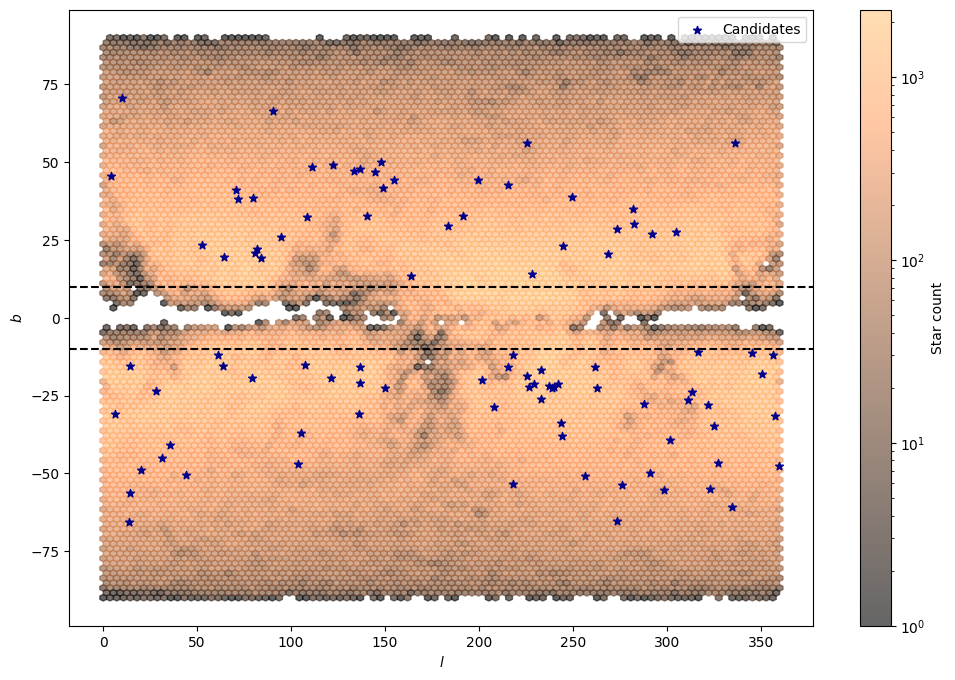

In [24]:
plt.figure(figsize=(12,8))
plt.hexbin(df_unwise_merge['l'], df_unwise_merge['b'], bins='log', gridsize=100,
           rasterized=True, cmap=cm.copper, alpha=.6);
plt.colorbar(label='Star count')
plt.scatter(df_unwise_merge['l'].iloc[idc_candidates], df_unwise_merge['b'].iloc[idc_candidates],
           s=35, c='darkblue', marker='*', label='Candidates');
plt.legend()
plt.axhline(-10, c='k', ls='--')
plt.axhline(10, c='k', ls='--')
plt.xlabel(r"$l$")
plt.ylabel(r"$b$")
#plt.savefig(folder_figs+'candidates_lb_92.pdf' , bbox_inches="tight", dpi=50)



## List of Gaia DR3 

In [157]:
small_tab_candi = df_unwise_merge[['source_id', 'DESIGNATION', 'ra_2', 'dec_2', 'ph_qual']].iloc[idc_candidates].reset_index(drop=True)
small_tab_candi.to_csv('/scratch/gcontard/infrared/list_candi_IRExcess_thresholdDeficit_94.csv')

## SphereX (I think this Table was a list of pre-selected "favored" ice-targets?)


In [42]:
from astropy.table import Table
sphe = Table.read('/scratch/gcontard/sphereX/20241107_SPLICESv8.6.fits', format='fits')

In [43]:
## SphereX

is_candi_in_spheICEs = []
for i in idc_candidates:
    allw = df_unwise_merge.iloc[i]['DESIGNATION']
    is_candi_in_spheICEs.append(np.isin(allw, sphe['designation'].value))

In [44]:
candi_insphex = idc_candidates[is_candi_in_spheICEs]
df_unwise_merge[['source_id', 'DESIGNATION', 'ra_2', 'dec_2']].iloc[candi_insphex]

,source_id,DESIGNATION,ra_2,dec_2
1091760,3017430205815280384,J055926.48-092154.2,89.860361,-9.365073
2777417,3004530769758177280,J061758.38-100221.4,94.493290,-10.039302


In [ ]:
## 

In [45]:
ids_in_sphe = []
for id_ in candi_insphex:
    ids_in_sphe.append(np.where(sphe['designation']==df_unwise_merge.iloc[id_]['DESIGNATION'])[0])

In [46]:
sphe[ids_in_sphe]

source_id,designation,ra,dec,GAL_LONG,GAL_LAT,tmassdesignation,tmassra,tmassdec,J,Jerr,H,Herr,K,Kerr,ph_qual,rd_flg,prox,W1,W1err,W2,W2err,W3,W3err,W4,W4err,cc_flags,ext_flg,var_flg,IRAC_designation,ra_IRAC,dec_IRAC,mag3_6,d3_6m,mag4_5,d4_5m,mag5_8,d5_8m,mag8_0,d8_0m,SEL_TYPE,CLASS_1,YSO_PUB,STYPE_ML,STYPE_ML_PROB1,STYPE_ML_PROB2,NAME,Gaia_DR3,GaiaDR3_G,GaiaDR3_Gerr,GaiaDR3_B,GaiaDR3_Berr,GaiaDR3_R,GaiaDR3_Rerr,Plx,e_Plx,pmra,pmra_err,pmdec,pmdec_err,Dist,e_Dist_upper,e_Dist_lower,CLASSvar,W1var,W1var_CLASS,W2var,W2var_CLASS,W1VARAVG,W2VARAVG,W1VARAMP,W2VARAMP,Av,MC,MC_Lon,MC_Lat,MC_Dist,MC_AvF,MC_Los,numGaiaNB,maxRmag,sumRflux,mainRflux,fluxratioGaia,minGaiaDist,minDistGaiaFlux,NoC,NoC_gl,NoC_gb,numIRACnbors,minDistIRAC,I1mag,maxI1mag,sumI1flux,mainI1flux,minDistI1flux,I2mag,maxI2mag,sumI2flux,mainI2flux,minDistI2flux,fluxratioI1,fluxratioI2,numVVVneighbors,minDistVVV,VVVJmag,maxVVVJmag,sumVVVJflux,mainVVVJflux,minDistVVVJFlux,VVVHmag,maxVVVHmag,sumVVVHflux,mainVVVHflux,minDistVVVHFlux,VVVKmag,maxVVVKmag,sumVVVKflux,mainVVVKflux,minDistVVVKFlux,fluxratioVVVJ,fluxratioVVVH,fluxratioVVVK,numUKSnbors,minDistUKS,UKSJmag,maxUKSJmag,sumUKSJflux,mainUKSJflux,minDistUKSJFlux,UKSHmag,maxUKSHmag,sumUKSHflux,mainUKSHflux,minDistUKSHFlux,UKSKmag,maxUKSKmag,sumUKSKflux,mainUKSKflux,minDistUKSKFlux,fluxratioUKSJ,fluxratioUKSH,fluxratioUKSK,VarClassGaia,VarClassGaiaSc,SV_W1,SV_W1_V,SV_W1_T,SV_W2,SV_W2_V,SV_W2_T
,,deg,deg,deg,deg,,deg,deg,mag,mag,mag,mag,mag,mag,,,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,,,,,deg,deg,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,mag,mag,mag,mag,mag,mag,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,pc,pc,pc,,,,,,mag,mag,mag,mag,mag,,deg,deg,pc,mag,,,mag,uJy,uJy,percent,arcsec,uJy,,deg,deg,,arcsec,mag,mag,uJy,uJy,uJy,mag,mag,uJy,uJy,uJy,percent,percent,,arcsec,mag,mag,uJy,uJy,uJy,mag,mag,uJy,uJy,uJy,mag,mag,uJy,uJy,uJy,percent,percent,percent,,arcsec,mag,mag,uJy,uJy,uJy,mag,mag,uJy,uJy,uJy,mag,mag,uJy,uJy,uJy,percent,percent,percent,,,,,,,,
int64[1],bytes19[1],float64[1],float64[1],float64[1],float64[1],bytes17[1],float64[1],float64[1],float32[1],float32[1],float32[1],float32[1],float32[1],float32[1],bytes3[1],int32[1],float64[1],float32[1],float32[1],float32[1],float32[1],float32[1],float32[1],float32[1],float32[1],bytes4[1],int16[1],bytes4[1],bytes27[1],float64[1],float64[1],float32[1],float32[1],float32[1],float32[1],float32[1],float32[1],float32[1],float32[1],bytes8[1],bytes5[1],int16[1],bytes17[1],float64[1],float64[1],bytes30[1],int64[1],float32[1],float64[1],float32[1],float64[1],float32[1],float64[1],float64[1],float32[1],float64[1],float32[1],float64[1],float32[1],float32[1],float32[1],float32[1],bytes4[1],bool[1],bytes1[1],bool[1],bytes1[1],float64[1],float64[1],float64[1],float64[1],float64[1],bytes20[1],float64[1],float64[1],float64[1],float64[1],bytes2[1],int16[1],float32[1],float64[1],float64[1],float64[1],float32[1],float64[1],float64[1],float64[1],float64[1],int16[1],float32[1],float32[1],float32[1],float64[1],float64[1],float64[1],float32[1],float32[1],float64[1],float64[1],float64[1],float64[1],float64[1],int16[1],float32[1],float32[1],float32[1],float64[1],float64[1],float64[1],float32[1],float32[1],float64[1],float64[1],float64[1],float32[1],float32[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],int16[1],float32[1],float32[1],float32[1],float64[1],float64[1],float64[1],float32[1],float32[1],float64[1],float64[1],float64[1],float32[1],float32[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],bytes26[1],float64[1],bytes1[1],float64[1],float64[1],bytes1[1],float64[1],float64[1]
2010821993934356481,J055926.48-092154.2,89.860369,-9.365107,215.52995688942593,-15.766766516657455,05592648-0921543,89.860369,-9.365107,13.033,0.024,12.725,0.027,12.594,0.028,AAA,222,34.5,12.278,0.023,11.868,0.021,9.01,0.03,8.354,0.357,0000,0,011n,--,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAIN,--,--,Class III YSO,0.8160310463874928,1.0,--,3017430205815280384,14.207283,0.002786,14.582232,0.

In [53]:
sphe.columns

<TableColumns names=('source_id','designation','ra','dec','GAL_LONG','GAL_LAT','tmassdesignation','tmassra','tmassdec','J','Jerr','H','Herr','K','Kerr','ph_qual','rd_flg','prox','W1','W1err','W2','W2err','W3','W3err','W4','W4err','cc_flags','ext_flg','var_flg','IRAC_designation','ra_IRAC','dec_IRAC','mag3_6','d3_6m','mag4_5','d4_5m','mag5_8','d5_8m','mag8_0','d8_0m','SEL_TYPE','CLASS_1','YSO_PUB','STYPE_ML','STYPE_ML_PROB1','STYPE_ML_PROB2','NAME','Gaia_DR3','GaiaDR3_G','GaiaDR3_Gerr','GaiaDR3_B','GaiaDR3_Berr','GaiaDR3_R','GaiaDR3_Rerr','Plx','e_Plx','pmra','pmra_err','pmdec','pmdec_err','Dist','e_Dist_upper','e_Dist_lower','CLASSvar','W1var','W1var_CLASS','W2var','W2var_CLASS','W1VARAVG','W2VARAVG','W1VARAMP','W2VARAMP','Av','MC','MC_Lon','MC_Lat','MC_Dist','MC_AvF','MC_Los','numGaiaNB','maxRmag','sumRflux','mainRflux','fluxratioGaia','minGaiaDist','minDistGaiaFlux','NoC','NoC_gl','NoC_gb','numIRACnbors','minDistIRAC','I1mag','maxI1mag','sumI1flux','mainI1flux','minDistI1flux','I2mag

In [56]:
uniqtypesphe, counttypesphe = np.unique(sphe['STYPE_ML'], return_counts=True)
for i in range(len(uniqtypesphe)):
    print(f"{uniqtypesphe[i]} : {counttypesphe[i]}")

-- : 1617276
AGN : 6912
C AGB : 2247487
Class I YSO : 5231
Class II YSO : 132946
Class III YSO : 469611
Flat spectrum YSO : 8816
MS Star : 5242474
O AGB : 194907


In [57]:
len(sphe)

9925660

In [51]:
sphe[ids_in_sphe].write("/scratch/gcontard/infrared/spherex_listofice_ourcandidates_2.fits", format='fits')

In [ ]:
## For some very opaque reason, I am missing one candidate from the previous run crossmatch with sphereX
## HOW AND WHY? 
## DR3 1990831460034019331 

## These two are considered young stellar object but i'd guess it's kind of the focus of that list of obj?

In [58]:
## NEAREST NEIGHBORS? As in paper to make a set of control neighbors, we don't use color as a feature

In [60]:
feature_neighbors_notcolor = ['M_G','ebpminrp_gspphot', 'parallax','ruwe','phot_g_mean_mag', 
                 'j_m', 'h_m', 'ks_m','phot_bp_mean_mag',
                 'phot_rp_mean_mag']

scaler_notcolor = MinMaxScaler()
scaler_notcolor.fit(df_unwise_merge[feature_neighbors_notcolor])
ft_neighbors_resc_notcol = scaler_notcolor.transform(df_unwise_merge[feature_neighbors_notcolor])

K_neig_valid = 21
nbrs_valid_notcol = NearestNeighbors(n_neighbors=K_neig_valid, algorithm='ball_tree', 
                              leaf_size=100,n_jobs=10).fit(ft_neighbors_resc_notcol)


In [72]:
sourceid_neighb_notcol, idc_neighb_notcol  = [], []
dupli_idcandi = []
for id_ in idc_candidates:
    d_,neighb_ = nbrs_valid_notcol.kneighbors(ft_neighbors_resc_notcol[id_].reshape(1,-1)) 
    d_ = d_[0][1:]
    neighb_ = neighb_[0][1:]
    for i in neighb_:
        sourceid_neighb_notcol.append(df_unwise_merge['source_id'].iloc[i])
        idc_neighb_notcol.append(i)
        dupli_idcandi.append(id_)

## We don't need the following here if we dont need to look at those ew_espels_halpha stuff:

# query_ = "SELECT * FROM gaiadr3.gaia_source_lite  AS dr3  JOIN gaiadr3.astrophysical_parameters \
#  AS astropara USING (source_id) JOIN gaiadr3.astrophysical_parameters_supp \
#  AS astropara_supp USING (source_id) WHERE (dr3.source_id IN ("

# for i in range(len(sourceid_neighb_notcol)-1):
#     query_+= f"{sourceid_neighb_notcol[i]},"
    
# query_ += f"{sourceid_neighb_notcol[i+1]}))"

# #print(query_)
# job = Gaia.launch_job_async(query_)
# r_neighb_notcol = job.get_results().to_pandas()
# print(len(sourceid_neighb_notcol), len(r_neighb_notcol))


In [93]:
sourceid_neighb_notcol[-10:]

[4605310641991353600,
 4440199867068903168,
 5677099424100532480,
 1432975847871143552,
 2136634461830967680,
 6885930923180979584,
 4500991521369312896,
 5709756053318570368,
 6821305684148596736,
 6727521976573534464]

In [86]:

## make sure r_neighb_notcol is ordered correctly

r_neighb_notcol = df_unwise_merge.iloc[idc_neighb_notcol].reset_index(drop=True)

r_neighb_notcol.loc[np.arange(len(r_neighb_notcol)),'target_sourceid'] = df_unwise_merge['source_id'].iloc[dupli_idcandi].values.astype(int)

r_neighb_small = r_neighb_notcol[['source_id', 'ra_2', 'dec_2', 'target_sourceid']]

In [89]:
r_neighb_small['target_sourceid'] = r_neighb_small['target_sourceid'].astype(int)
r_neighb_small

/tmp/ipykernel_4242/2097274400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r_neighb_small['target_sourceid'] = r_neighb_small['target_sourceid'].astype(int)


,source_id,ra_2,dec_2,target_sourceid
0,1643251742966448640,241.972916,66.528169,2891595017027132416
1,4967031344549721856,36.449359,-34.681810,2891595017027132416
2,586704047441437696,139.158932,6.704747,2891595017027132416
3,5005367844675499776,9.595843,-34.382383,2891595017027132416
4,1146307602864963968,155.975410,82.035957,2891595017027132416
...,...,...,...,...
1875,6885930923180979584,318.084055,-12.449163,619195165798222208
1876,4500991521369312896,268.319730,15.930788,619195165798222208
1877,5709756053318570368,127.661247,-17.183445,619195165798222208
1878,6821305684148596736,336.313104,-20.249039,619195165798222208


In [ ]:
## Save the Gaia DR3 source_id of the neighbors in a csv where there is Gaia DR3 source_id (or designation) (neighbor),
## ra, dec, Designation, Gaia DR3 source_id (target)
## so the last column will have duplicate, to find the neighbors you do
## neighbors_table[neighbors_table['target_sourceid']==sourceid_of_targetcandidate]


In [155]:
r_neighb_small.to_csv('/scratch/gcontard/infrared/smallDR3table_neighbors_of94_candi.csv')
r_neighb_notcol.to_csv('/scratch/gcontard/infrared/fullDR3tab_neighbors_of94_candi.csv')

## A function to make some imaging (This can be ran with only the small_tab_candi / or any table that has ra/dec)

In [140]:


from astroquery.skyview import SkyView

def string_radec_gaia(df_, loc):
    return str(df_['ra_2'].loc[loc]) + " " + str(df_['dec_2'].loc[loc])
    
# def string_radec_gaia(df_, loc):
#     return str(df_['ra_gaia'].loc[loc]) + " " + str(df_['dec_gaia'].loc[loc])

    
def plot_candi_img(df_, id_, arcmin_size=2):

    sourceid = df_['source_id'].iloc[id_]
 
    
    arcmin_size_targ = arcmin_size

    fig, axs_ =  plt.subplots(1,4, figsize=(10*4, 8))
       #[fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1,2]), fig.add_subplot(gs[2,2])]

    label_misss =['DSS', r"$W1$", r'$W2$', r'$W3$']
    name_misss = [['DSS'],['WISE 3.4'], ['WISE 4.6'], ['WISE 12']]
    
    for i in range(4):
        axs = axs_[i]
        name_miss = name_misss[i]
        flag_query = True
        tryout=1
        while (flag_query & (tryout<12)):
            try:
                paths = SkyView.get_images(position=string_radec_gaia(df_unwise_merge,id_),
                                   coordinates='ICRS', #grid=True, gridlabels=True,
                                 #  radius = 5 * u.arcmin,
                               #    width = u.Quantity(5, unit=u.arcmin), height=u.Quantity(5, unit=u.arcmin),
                              #    width= 5 * u.arcmin, height= 5 * u.arcmin    ,
                                   survey=name_miss)
                flag_query = False
            except:
                print(f"Retrying gaia query for the {tryout} time")
                tryout+=1
                
        if flag_query:
           print(f"Couldn't download {name_miss}")

        else:

        ## Get recut  [61:-61]

            if len(paths)>0:
                img_ = paths[0][0].data
                pxlscale = 0
                shape_img_x, shape_img_y = img_.shape[0], img_.shape[1]
    
                #assert img_.shape[0]==img_.shape[1]
    
    
                for ik in paths[0][0].header['COMMENT']:
                    if ik.split(':')[0]=='PixelScale':
                        pxlscale = float(ik.split(':')[1].split("\"")[0].strip())
    
                totalarcmin_x, totalarcmin_y = shape_img_x * pxlscale / 60., shape_img_y * pxlscale / 60.
                px_to_remove_x = int((shape_img_x - arcmin_size_targ / (totalarcmin_x/shape_img_x))/2)
                px_to_remove_y = int((shape_img_y - arcmin_size_targ / (totalarcmin_y/shape_img_y))/2)
                assert px_to_remove_x>=0
                assert px_to_remove_y>=0
    
                img_ = img_[px_to_remove_x:-px_to_remove_x,px_to_remove_y:-px_to_remove_y]
                #print(px_to_remove)
                L, H = np.percentile(img_, [2.5, 97.5])
    
                m_ = axs.imshow(img_,cmap=cm.hot, #vmin=L, vmax=(3*H-2*L),
                                    interpolation='nearest', origin='lower')
                axs.scatter(img_.shape[0]/2, img_.shape[1]/2, 
                                                           s=450, facecolors='none', edgecolors='cyan')
                axs.set_title(f"{name_miss[0]}", y=0.98)
                plt.colorbar(m_, ax=axs,fraction=0.046, pad=0.04)#, extend='both')
    
                onearcmin_x = 1/(totalarcmin_x/shape_img_x)
                axs.plot([ img_.shape[0]/2 - onearcmin_x/2, 
                             img_.shape[0]/2 + onearcmin_x/2], [13, 13], color='cyan', marker='|', lw=1)
                axs.text(img_.shape[0]/2 , 1, "1\'", color='cyan')
                #axs[2].tight_layout()
                axs.set_title(f"{label_misss[i]}")
                axs.axis('off')
    
    
    
    plt.tight_layout()
    plt.suptitle(f"Gaia DR3 {sourceid}, {df_['ph_qual'].iloc[id_]}")
    plt.show()
    

## It would be however quite helpful to have some way to do the SED fit on more data to calculate the "proper"(?) fractional luminosities and restric the dataset to the most infrared-excessive candidates? 

Although we _can_ do this with the current data to some extent but it would not be proper fractional _luminosity_ ? 

In [134]:
import matplotlib
matplotlib.rcParams['font.size'] = '22'

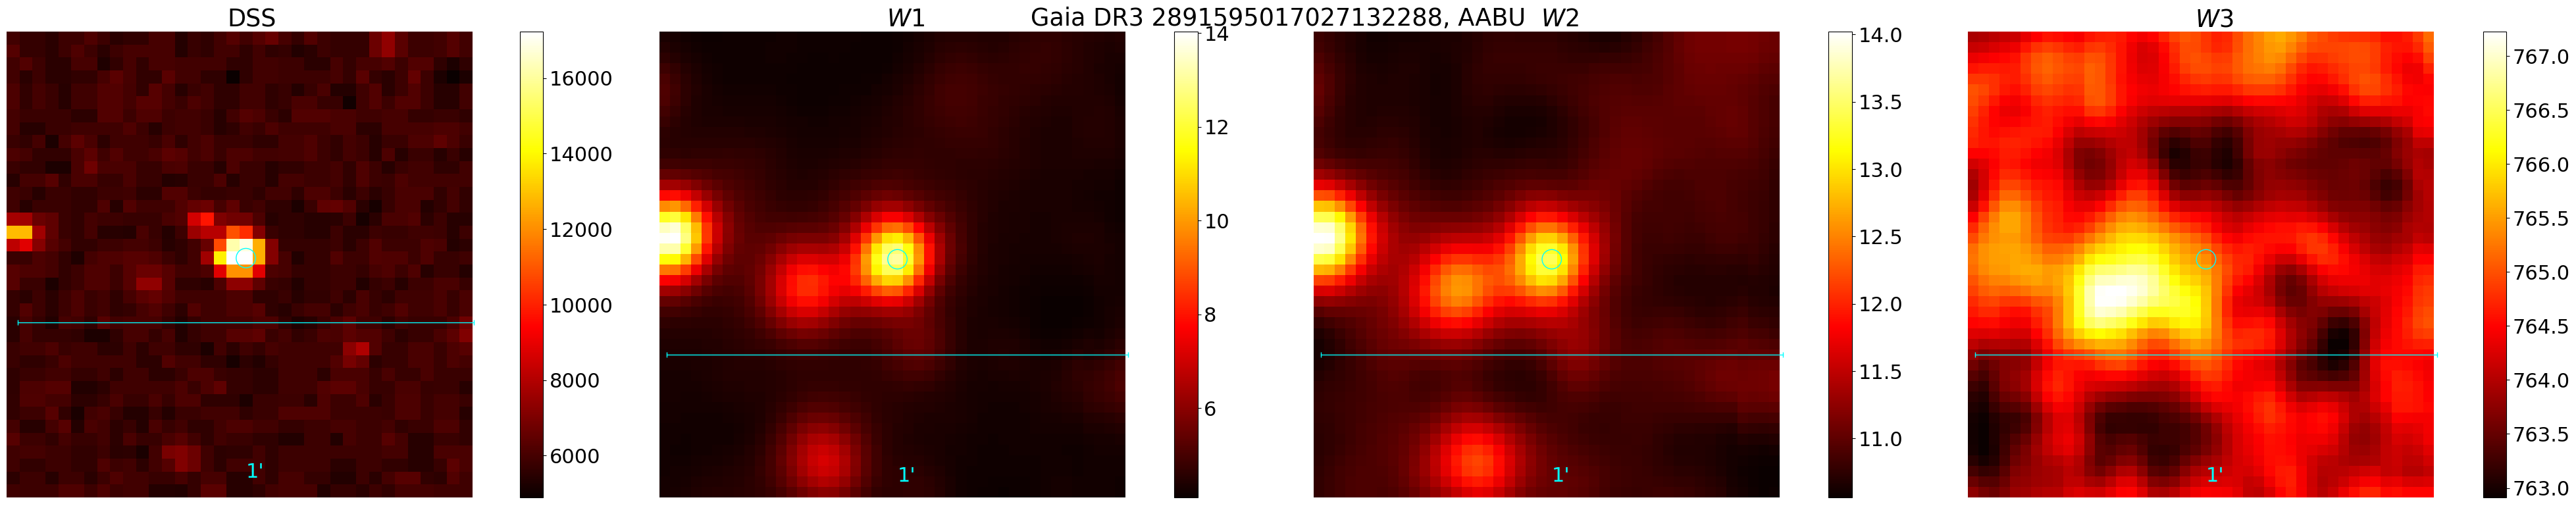

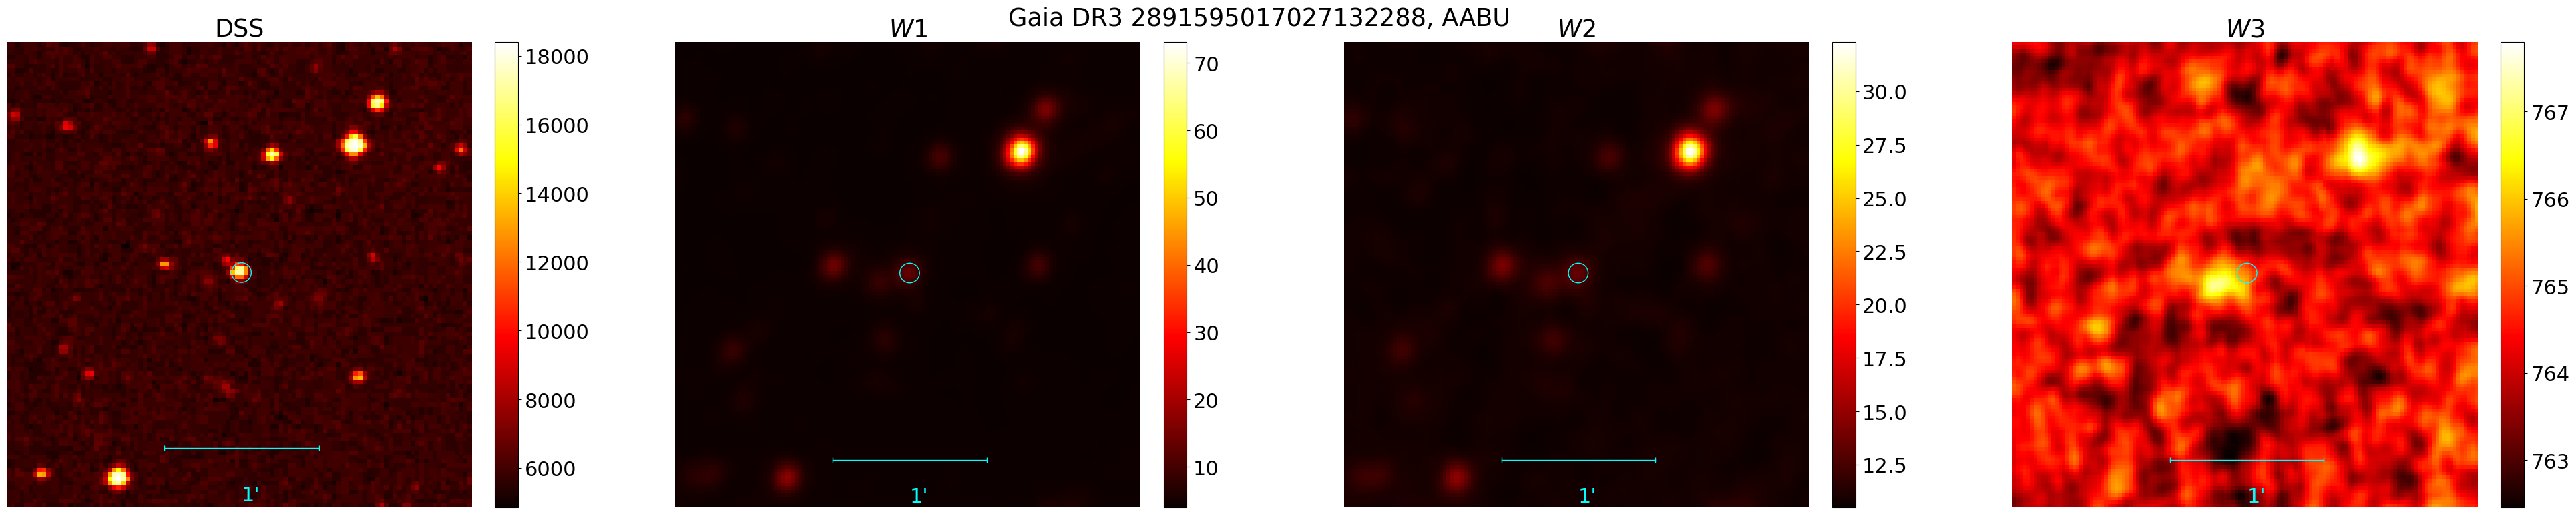

--------------------------------------------------------------------------------





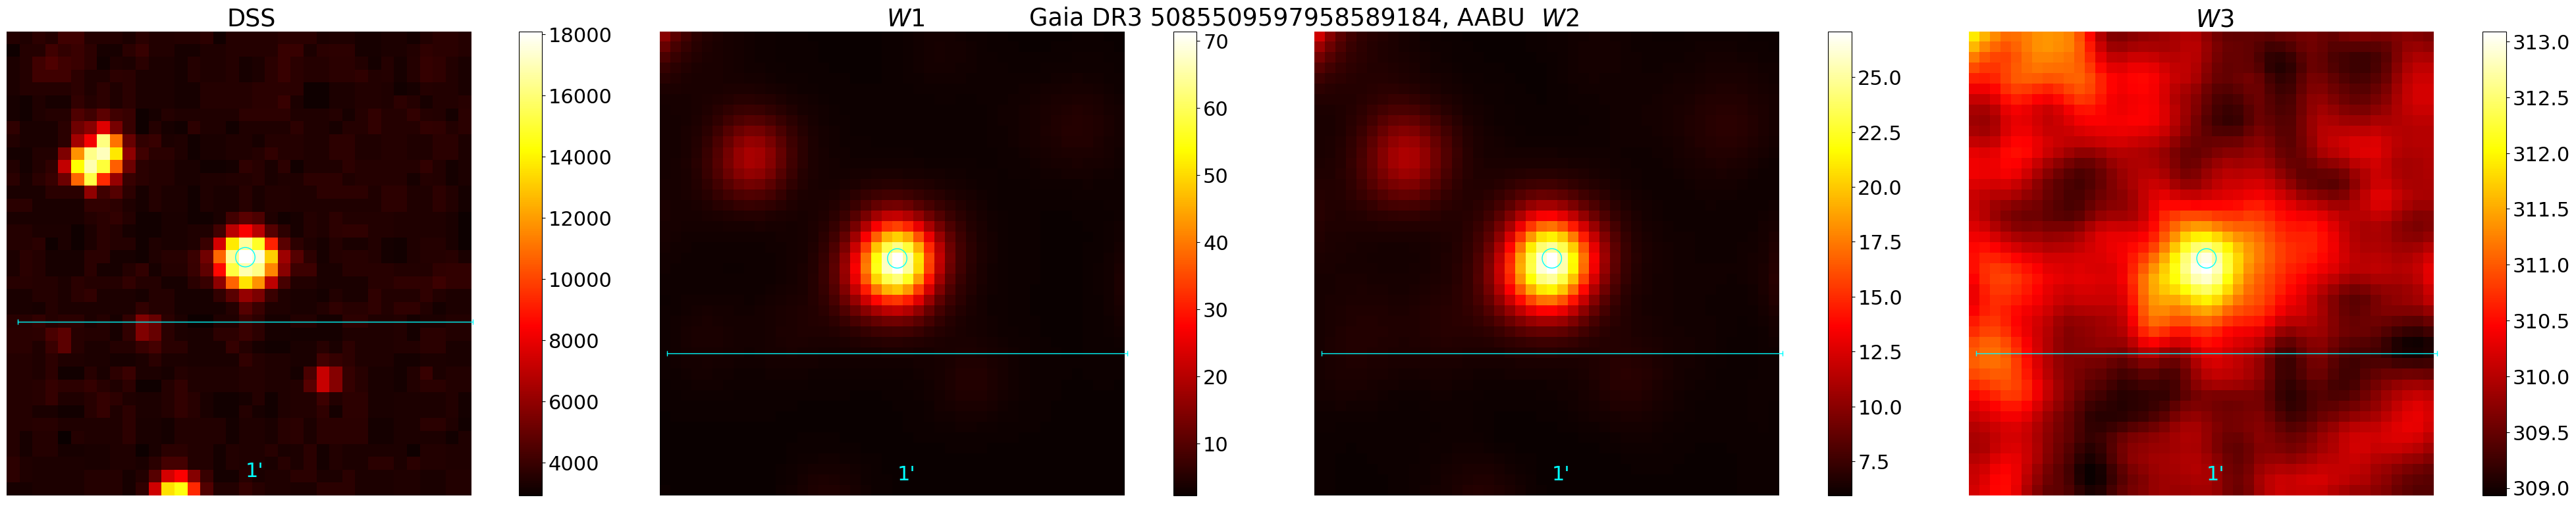

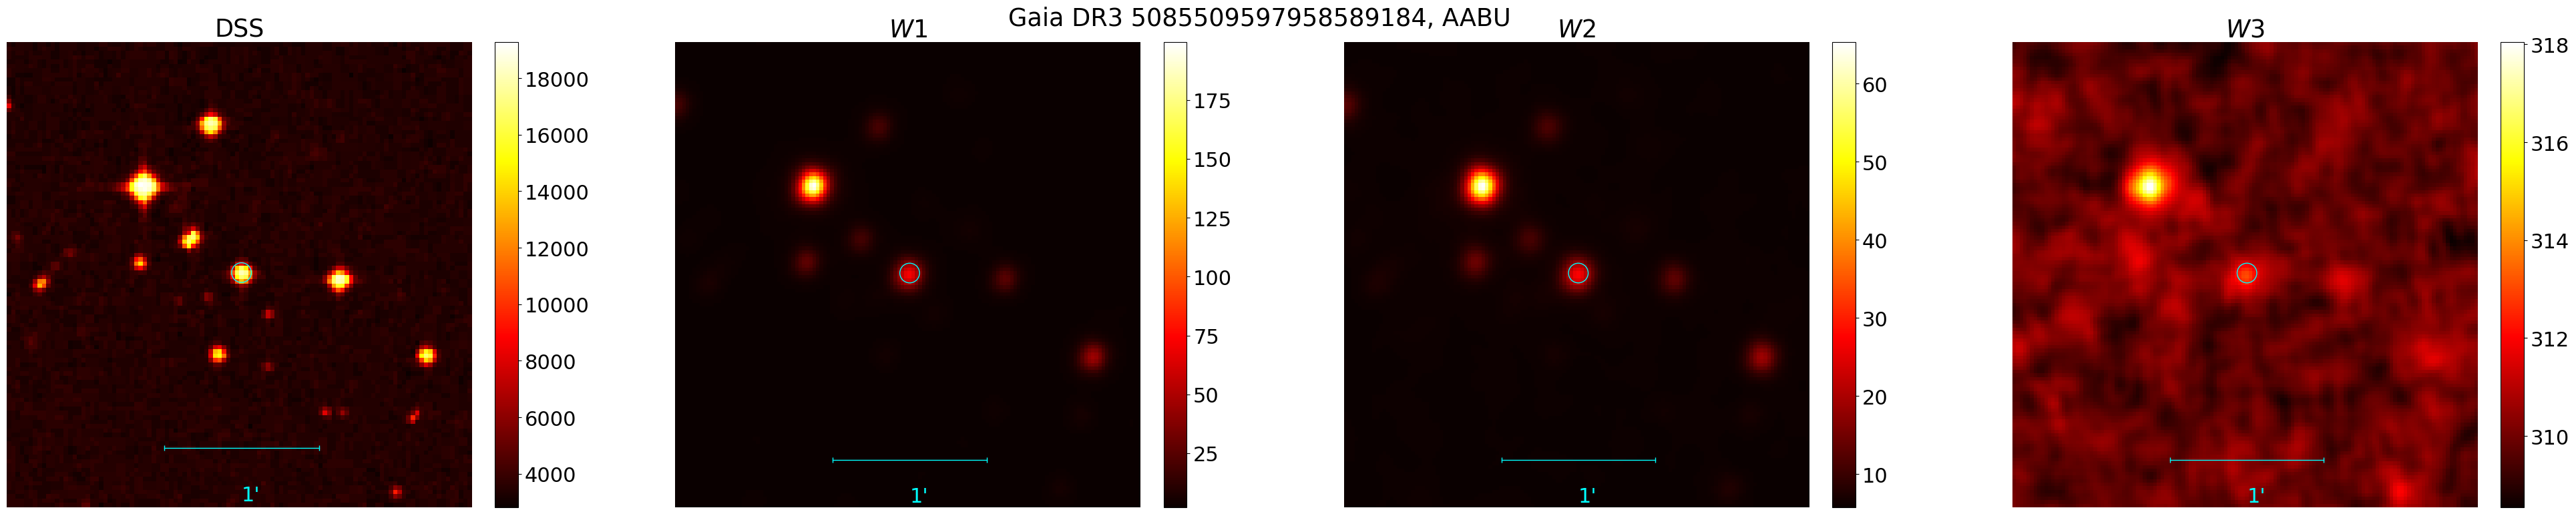

--------------------------------------------------------------------------------





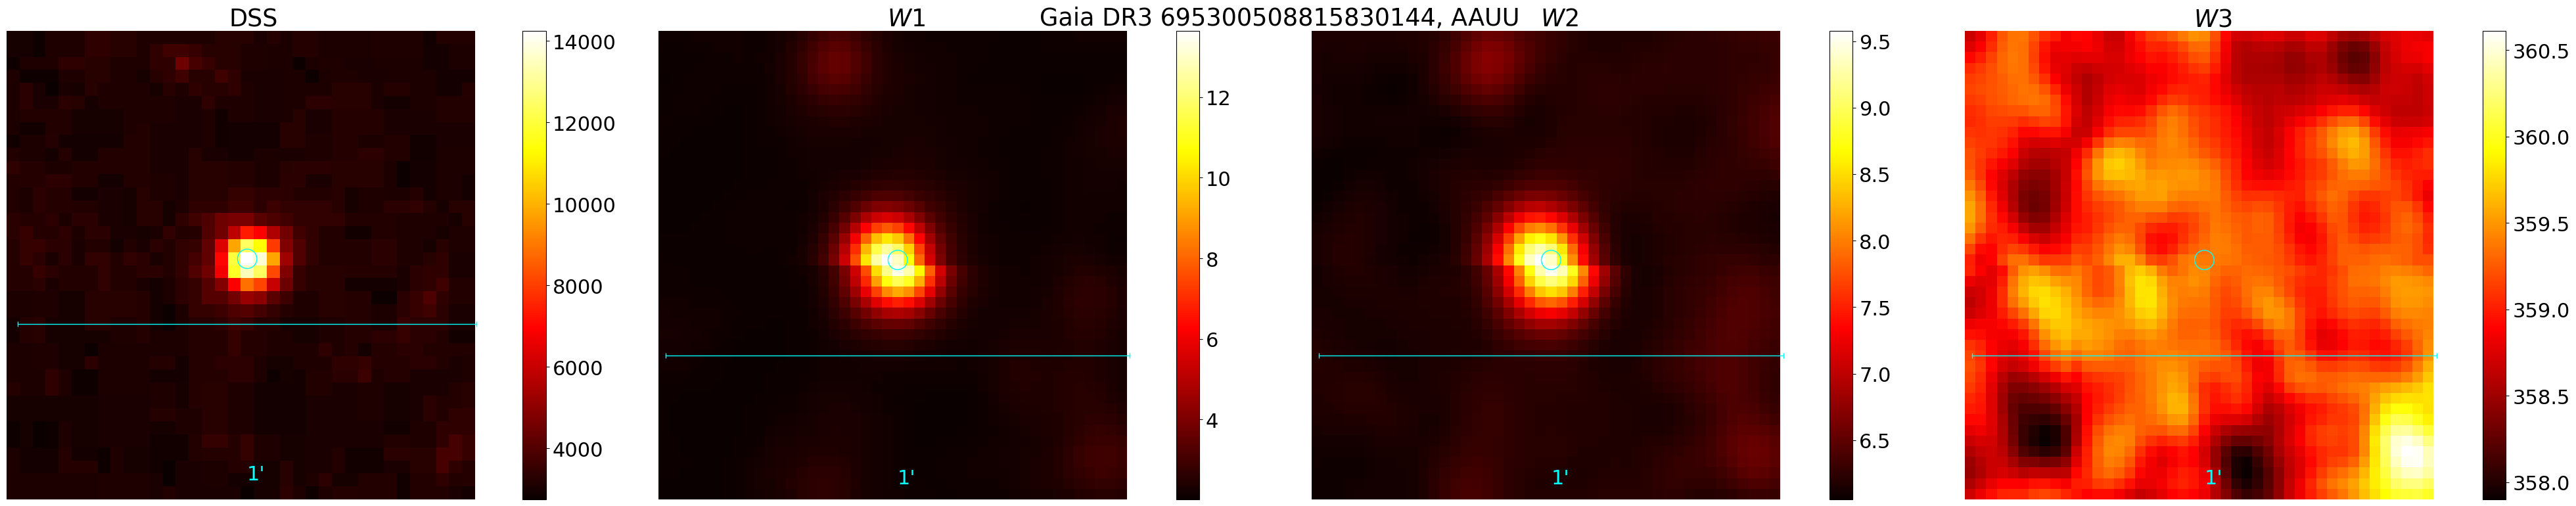

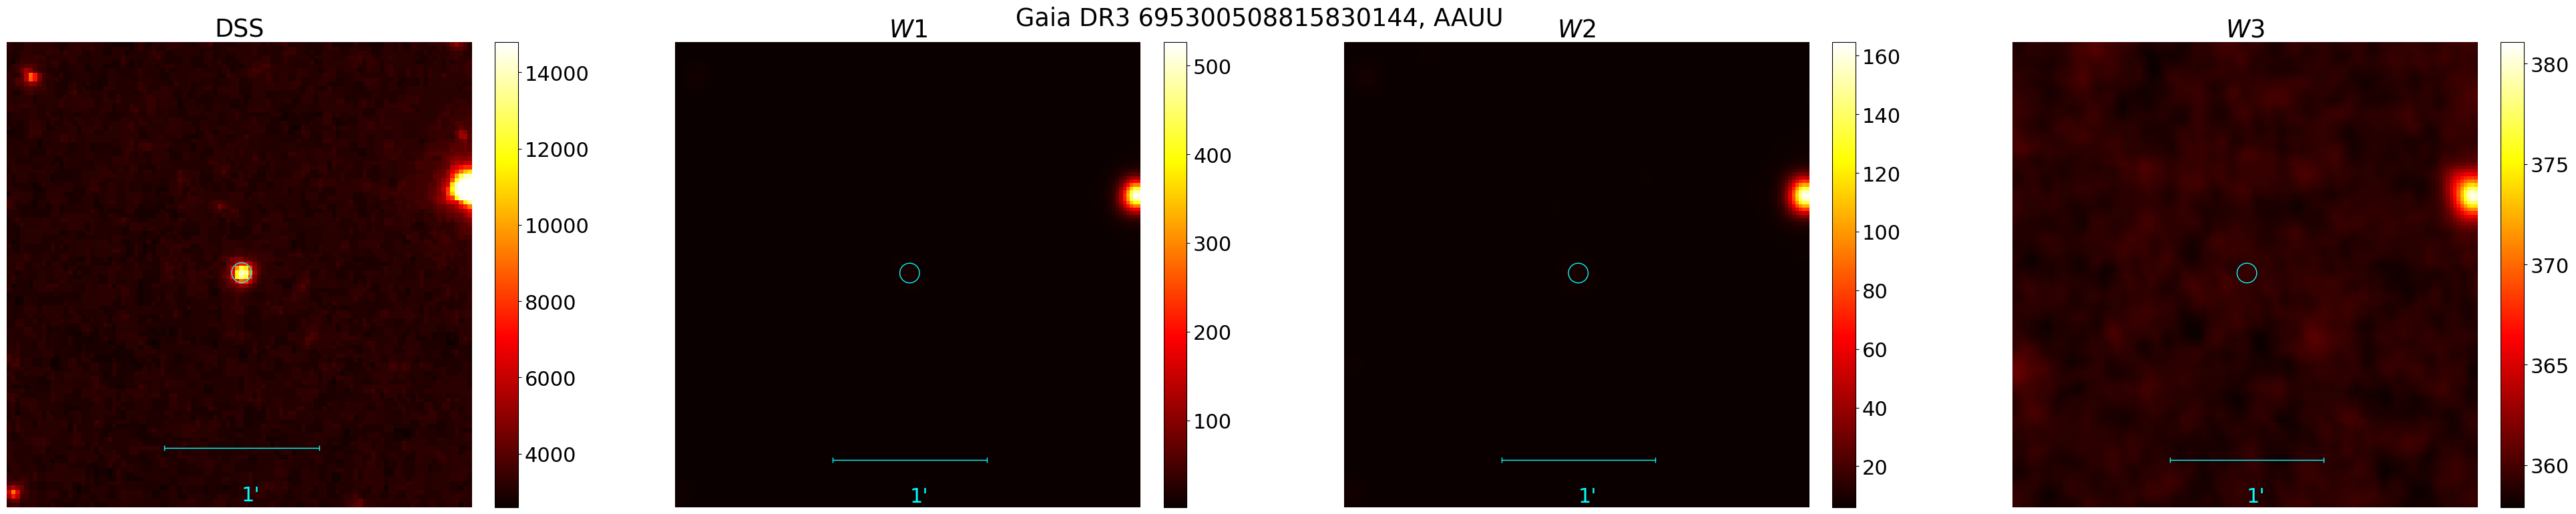

--------------------------------------------------------------------------------





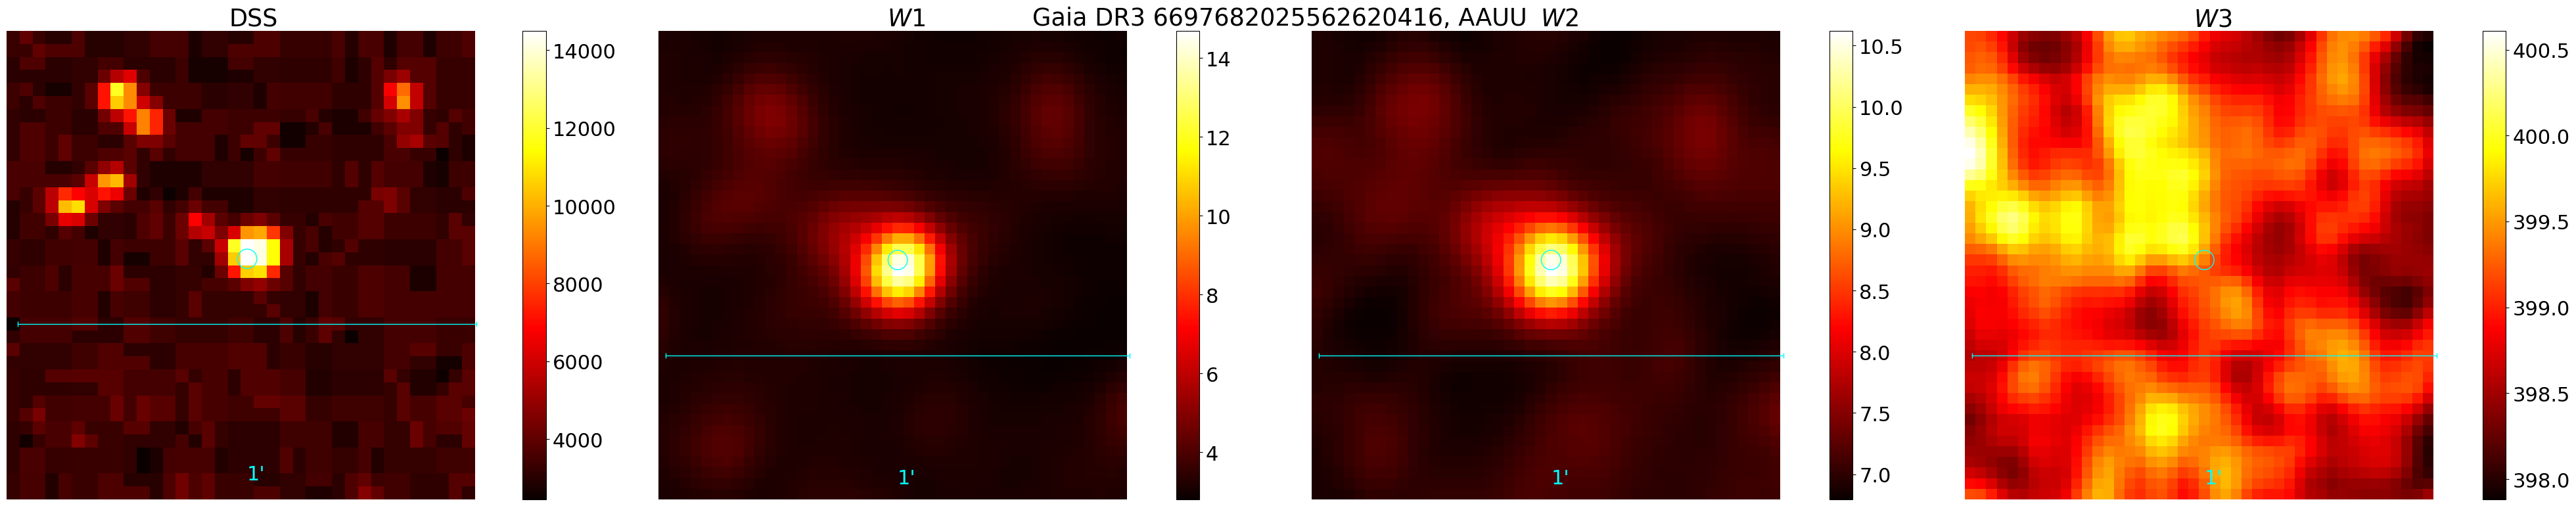

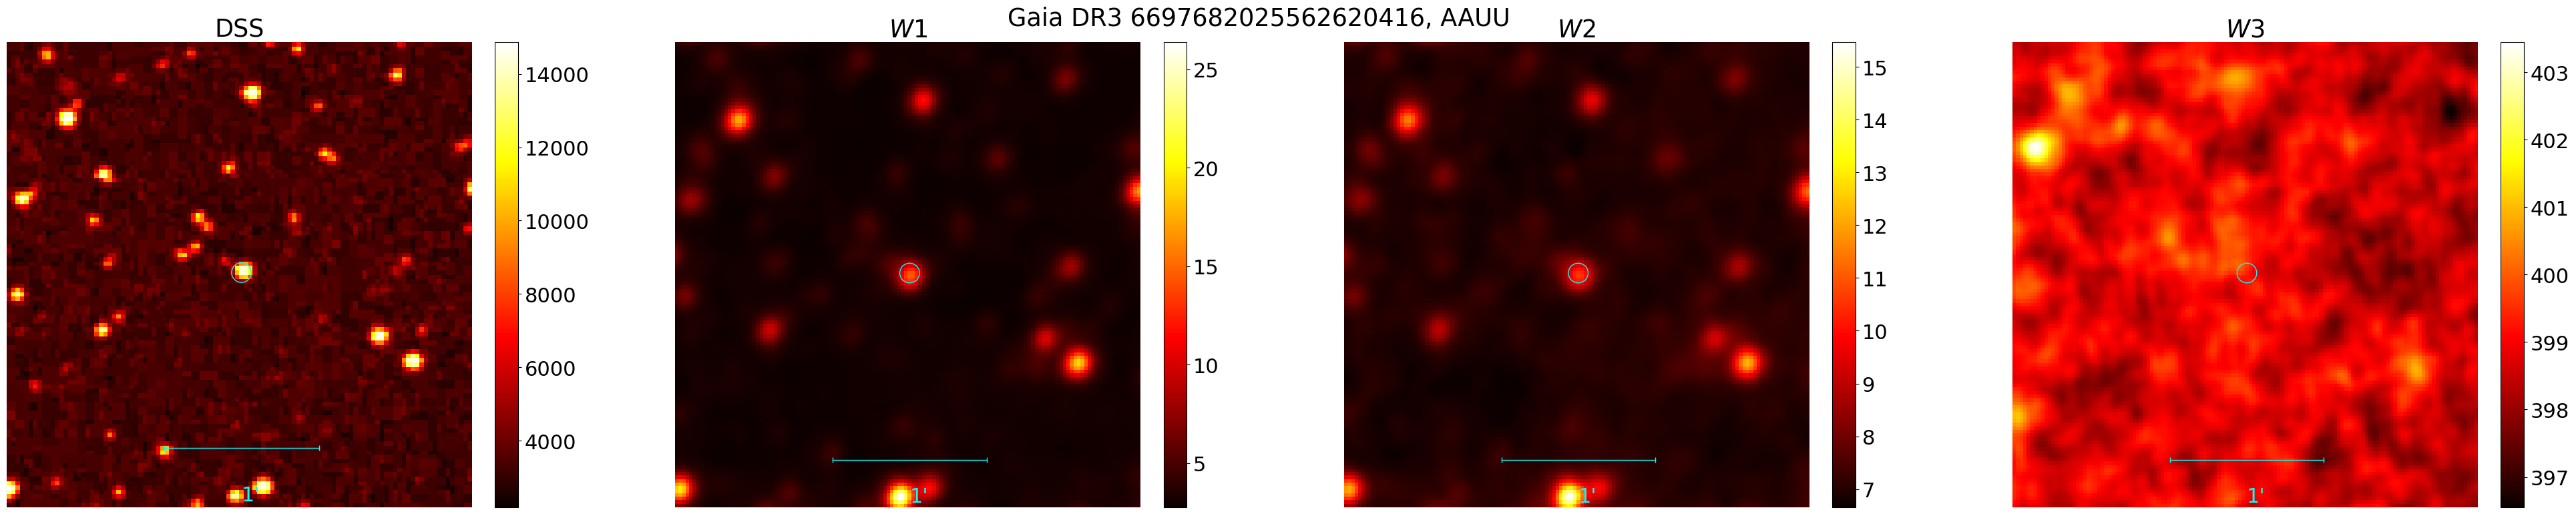

--------------------------------------------------------------------------------





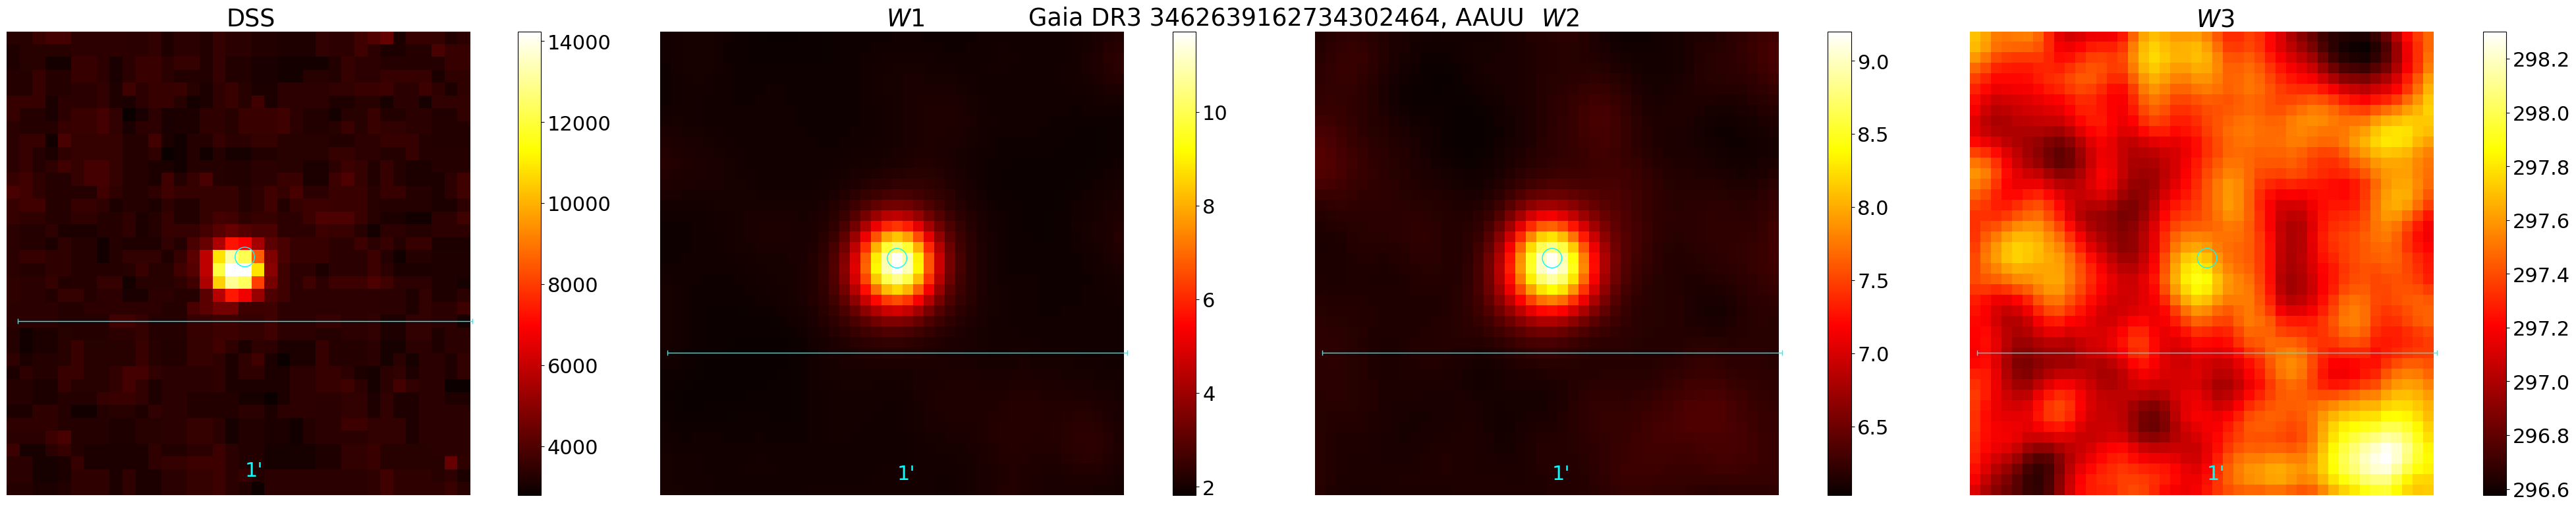

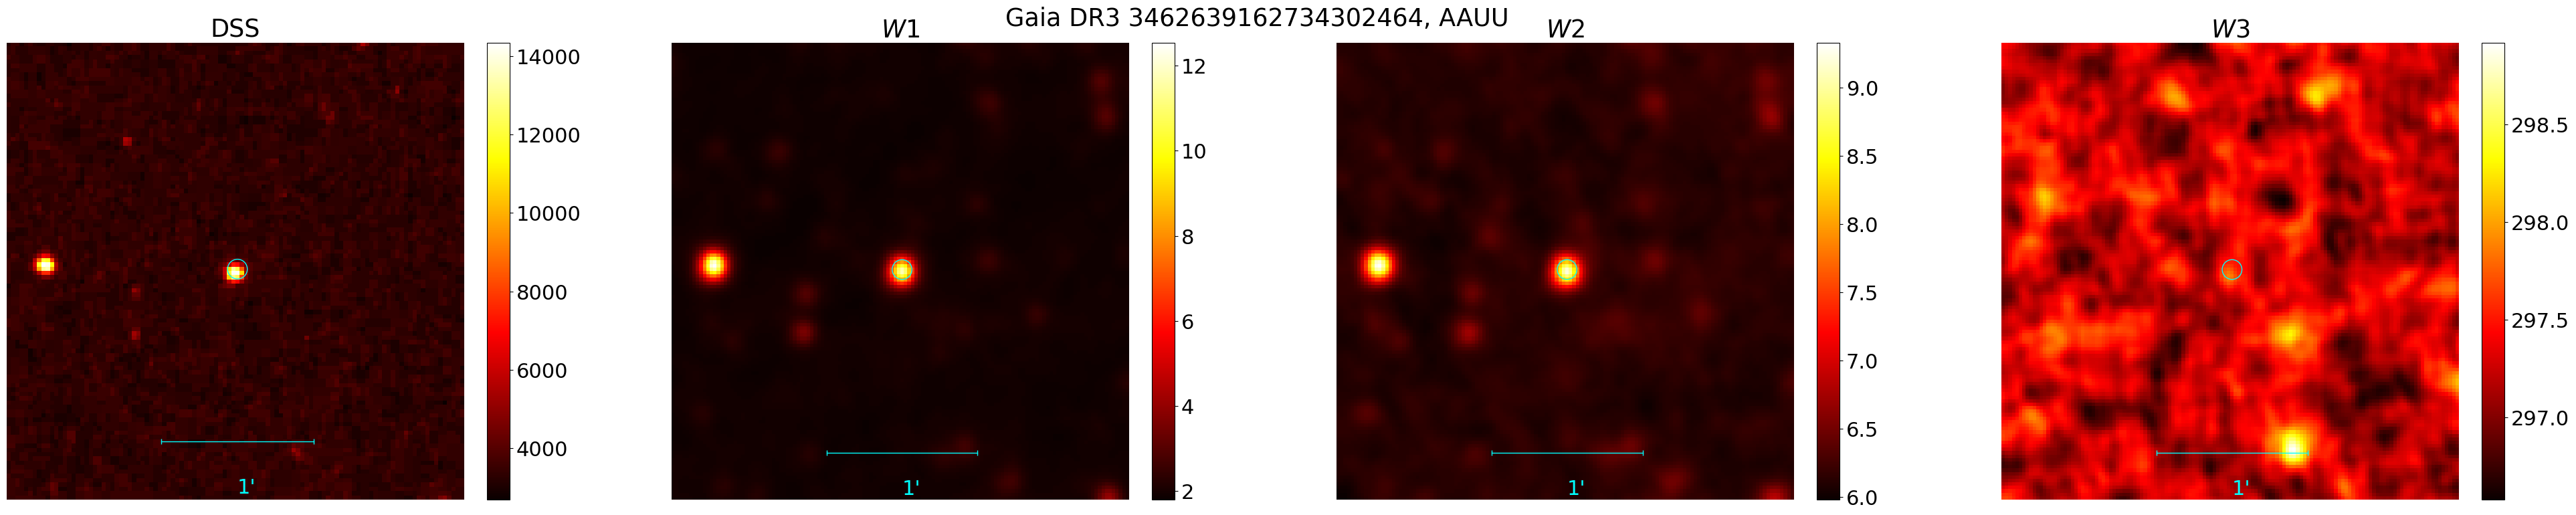

--------------------------------------------------------------------------------





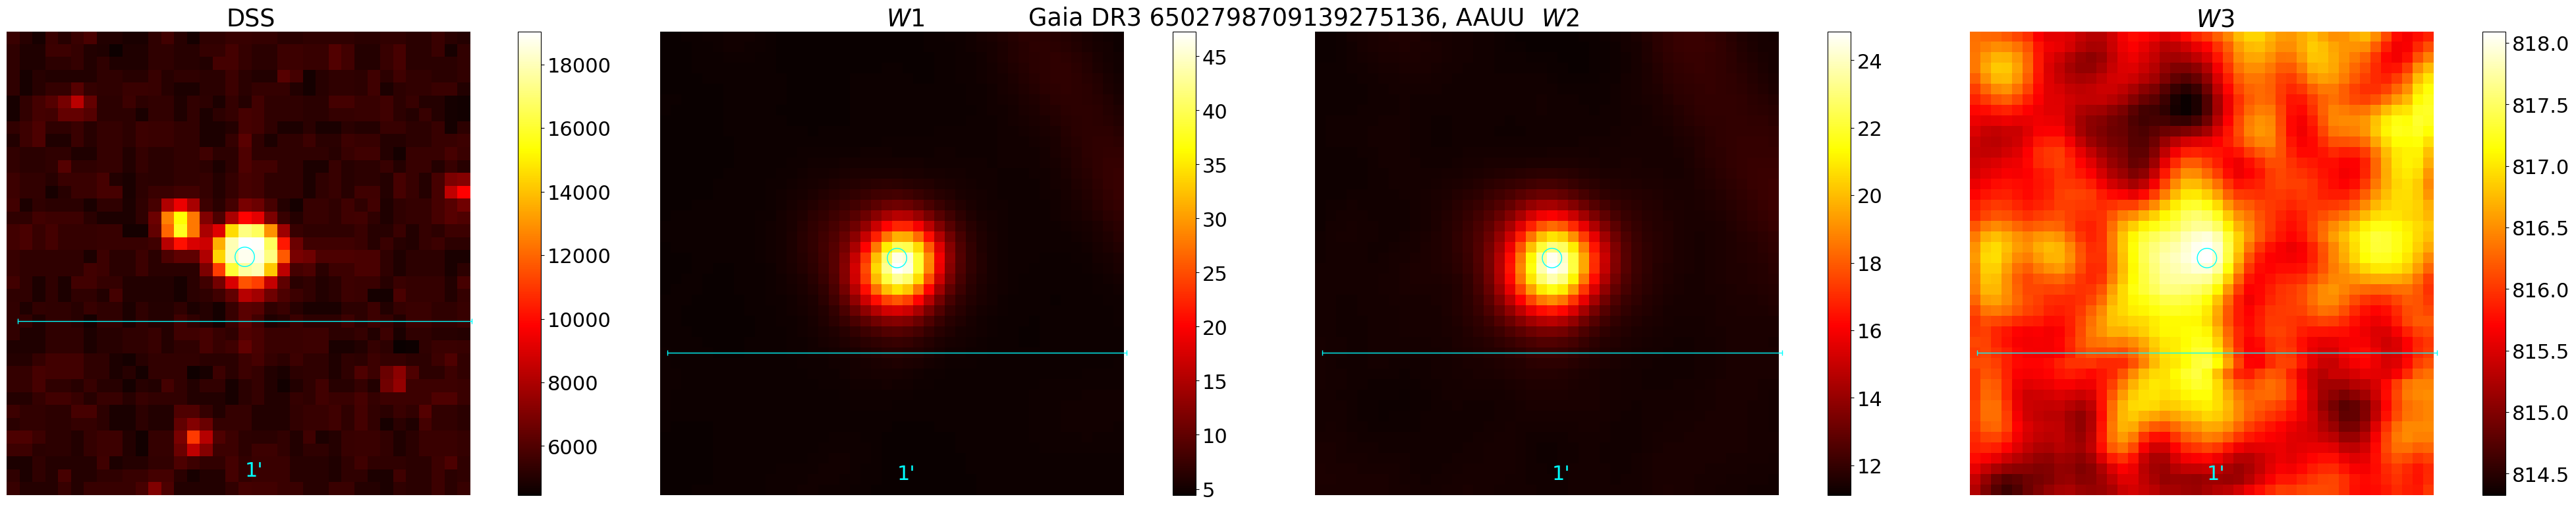

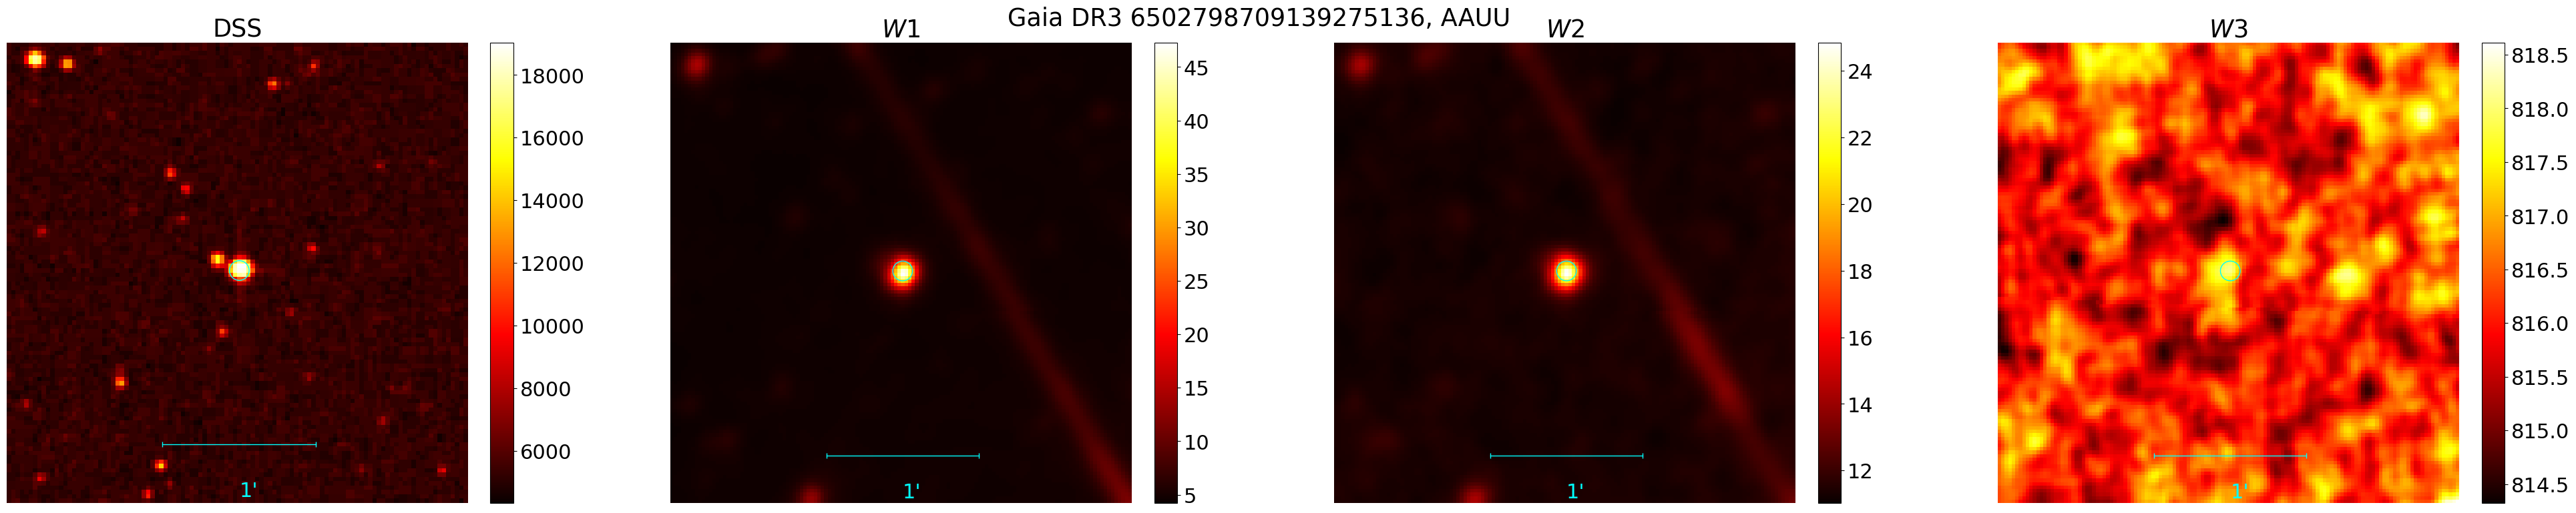

--------------------------------------------------------------------------------





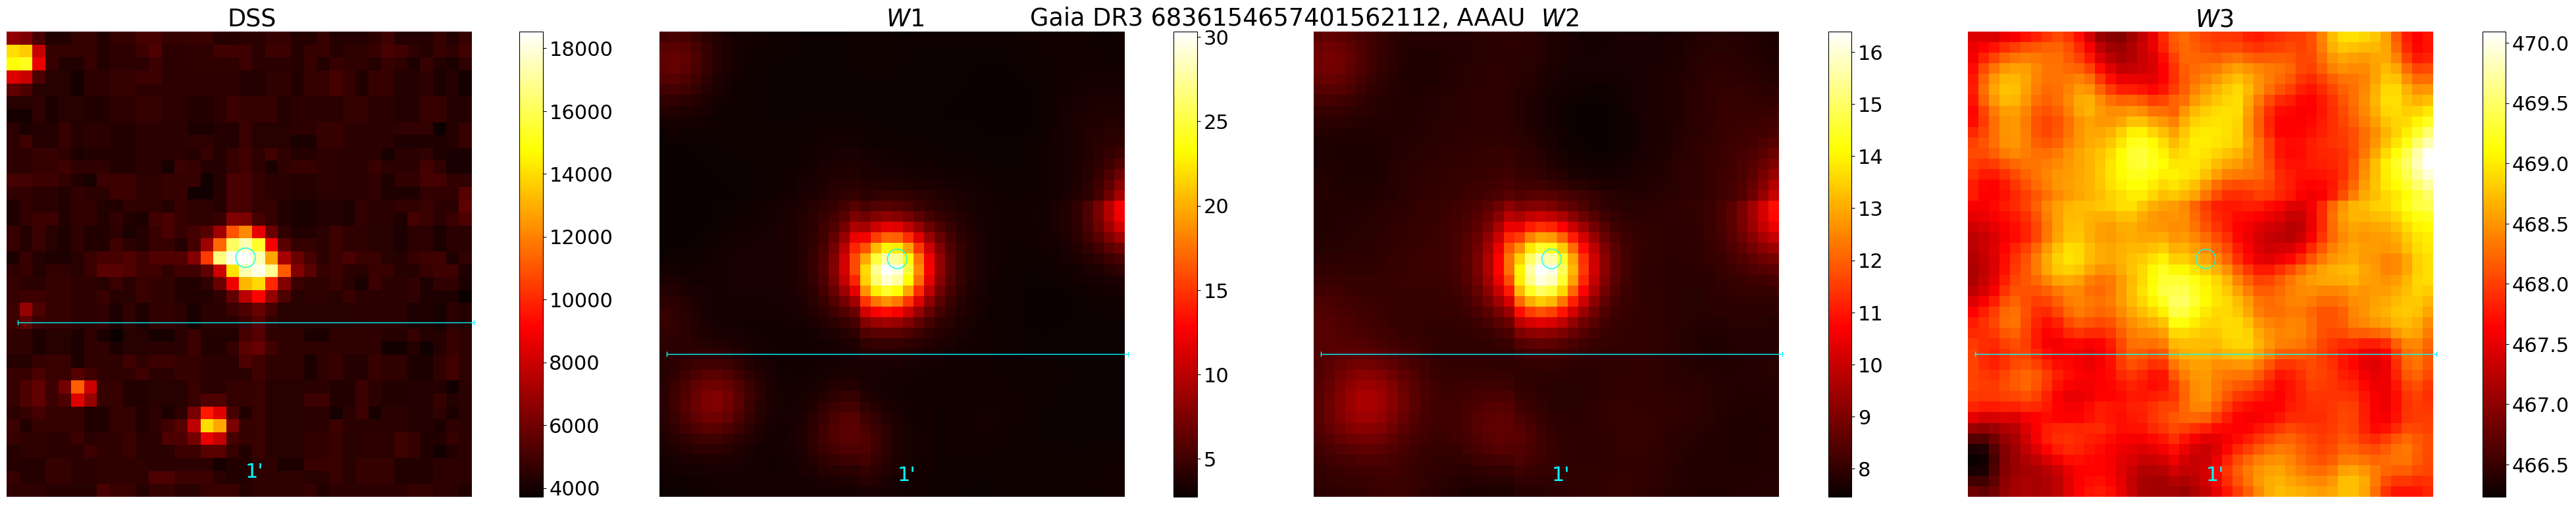

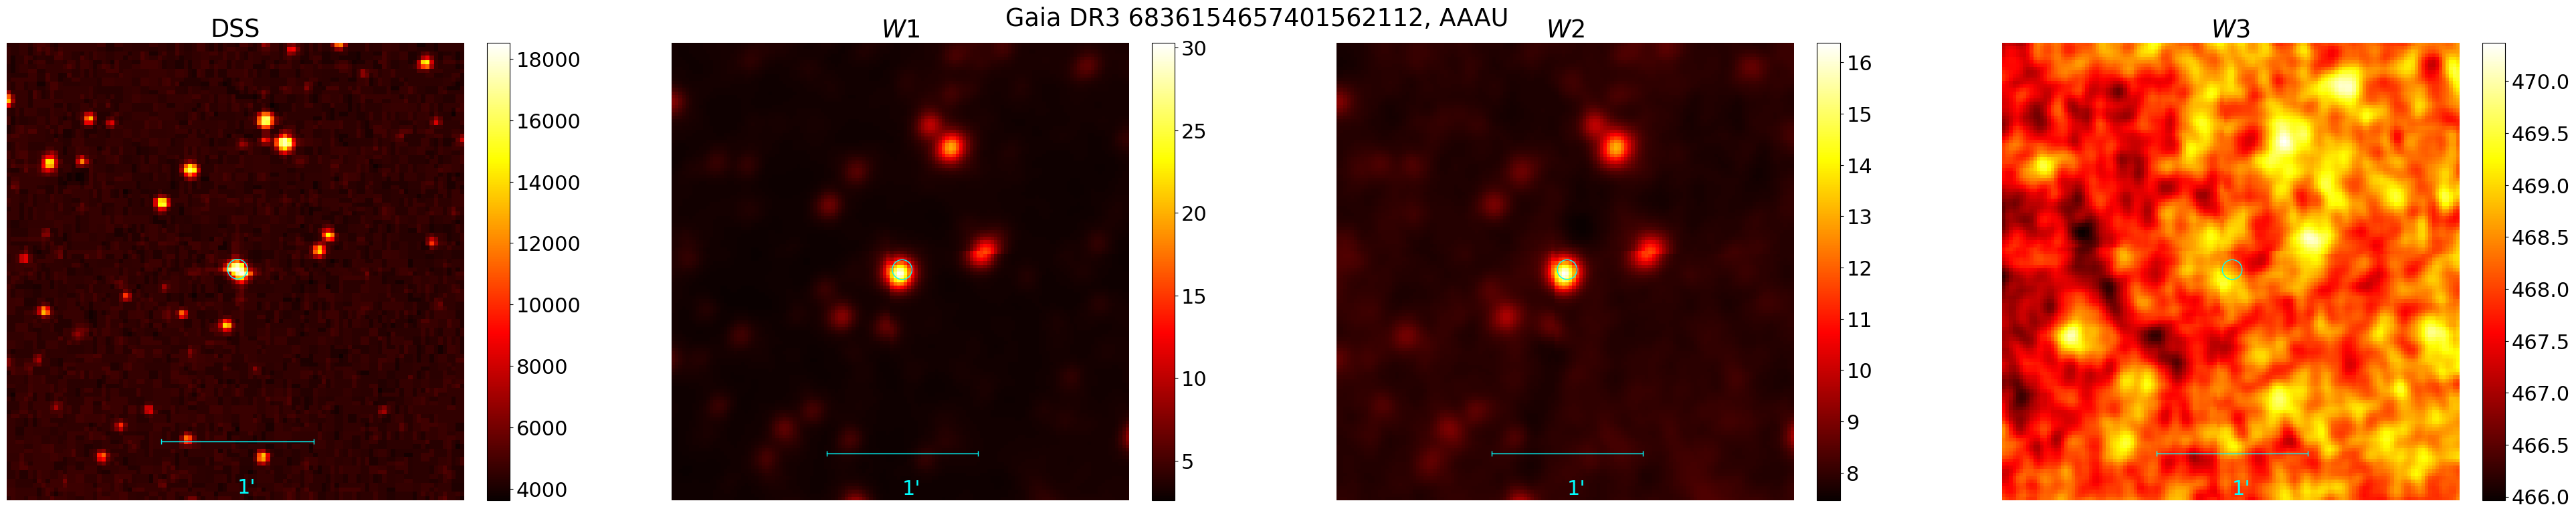

--------------------------------------------------------------------------------





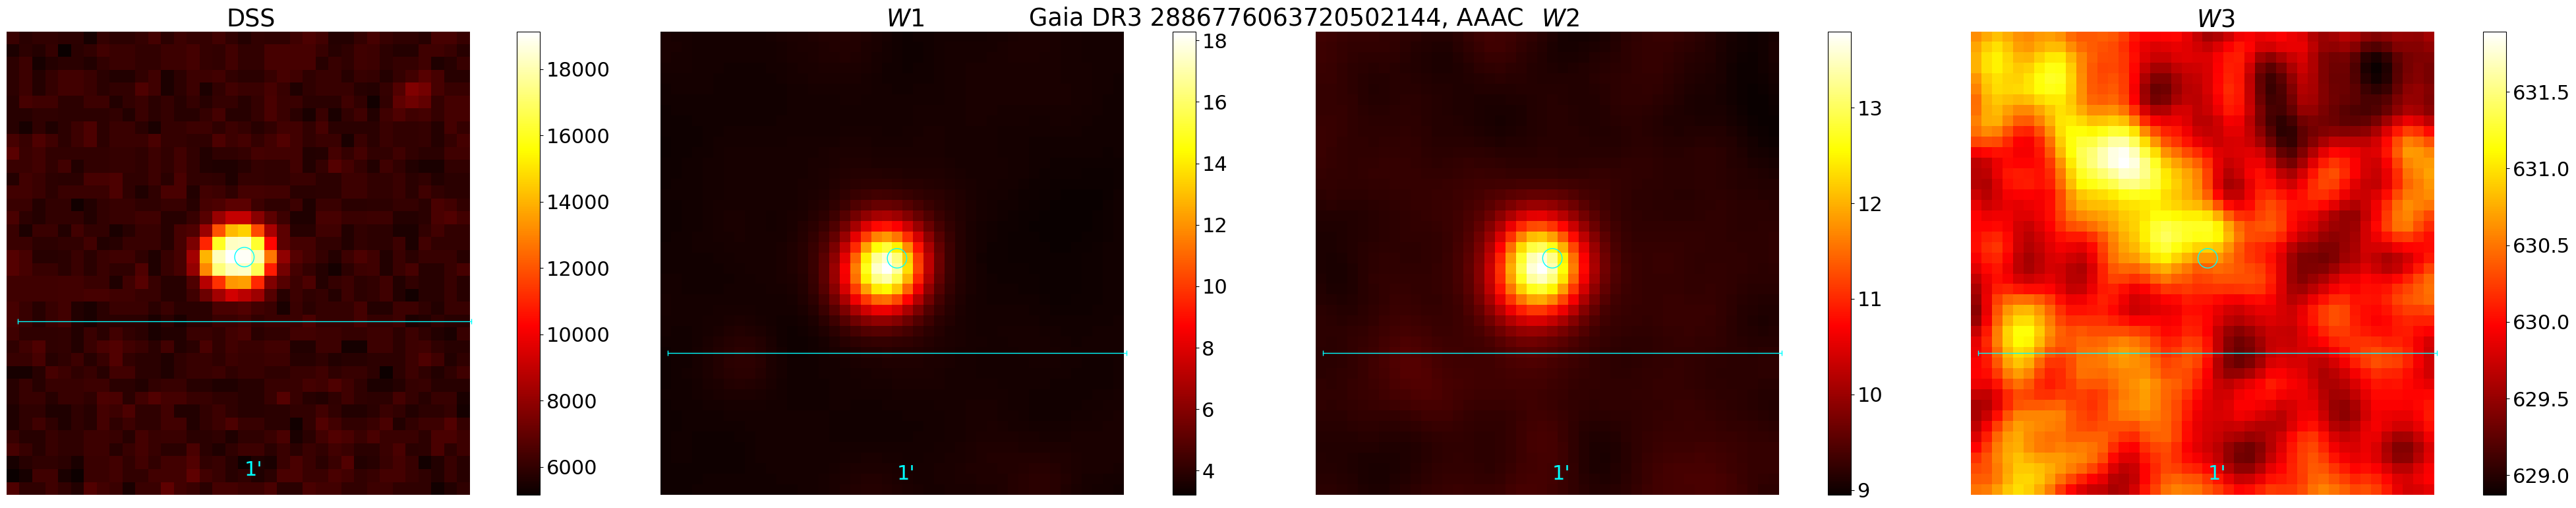

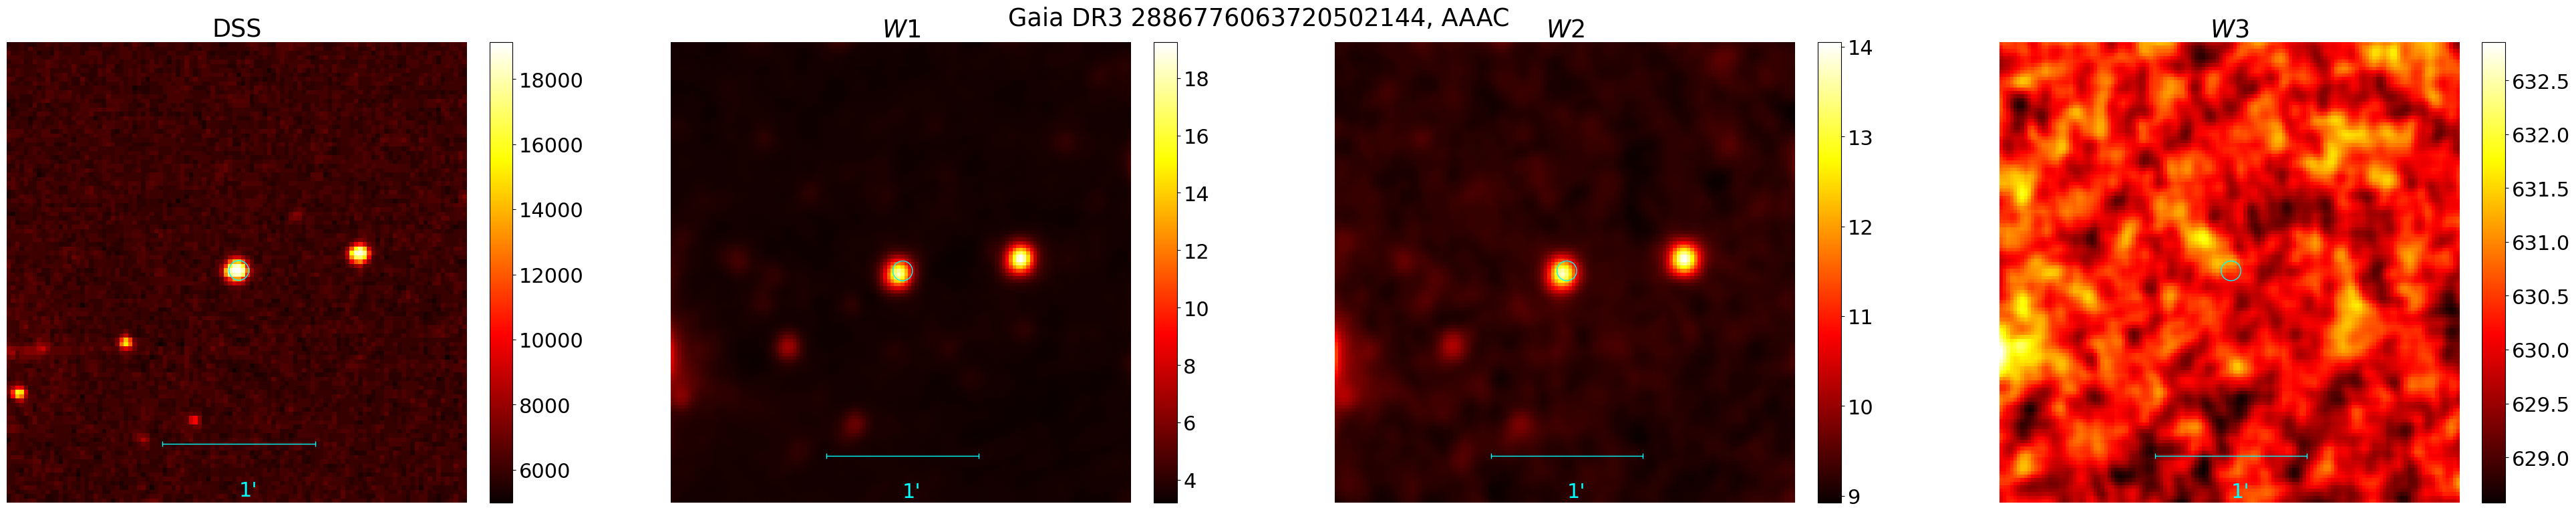

--------------------------------------------------------------------------------



Retrying gaia query for the 1 time
Retrying gaia query for the 2 time
Retrying gaia query for the 3 time
Retrying gaia query for the 4 time
Retrying gaia query for the 5 time
Retrying gaia query for the 6 time
Retrying gaia query for the 7 time


In [ ]:
for i in range(len(small_tab_candi)): #idc_candidates:
    plot_candi_img(small_tab_candi, i, arcmin_size=1) #plot_candi_img(df_unwise_merge, i, arcmin_size=1)
    
    plot_candi_img(small_tab_candi, i, arcmin_size=3) #plot_candi_img(df_unwise_merge, i, arcmin_size=3)
    print("--------"*10)
    print("\n\n")

## Plotting with Hogg trick for the colorbar range?


In [ ]:


def plot_candi_img_colorrange(df_, id_, arcmin_size=2):

    sourceid = df_['source_id'].iloc[id_]
 
    
    arcmin_size_targ = arcmin_size

    fig, axs_ =  plt.subplots(1,4, figsize=(10*4, 8))
       #[fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1,2]), fig.add_subplot(gs[2,2])]

    label_misss =['DSS', r"$W1$", r'$W2$', r'$W3$']
    name_misss = [['DSS'],['WISE 3.4'], ['WISE 4.6'], ['WISE 12']]
    
    for i in range(4):
        axs = axs_[i]
        name_miss = name_misss[i]
        flag_query = True
        tryout=1
        while (flag_query & (tryout<12)):
            try:
                paths = SkyView.get_images(position=string_radec_gaia(df_unwise_merge,id_),
                                   coordinates='ICRS', #grid=True, gridlabels=True,
                                 #  radius = 5 * u.arcmin,
                               #    width = u.Quantity(5, unit=u.arcmin), height=u.Quantity(5, unit=u.arcmin),
                              #    width= 5 * u.arcmin, height= 5 * u.arcmin    ,
                                   survey=name_miss)
                flag_query = False
            except:
                print(f"Retrying gaia query for the {tryout} time")
                tryout+=1
                
        if flag_query:
           print(f"Couldn't download {name_miss}")

        else:
            if len(paths)>0:
                img_ = paths[0][0].data
                pxlscale = 0
                shape_img_x, shape_img_y = img_.shape[0], img_.shape[1]
    
                #assert img_.shape[0]==img_.shape[1]
    
    
                for ik in paths[0][0].header['COMMENT']:
                    if ik.split(':')[0]=='PixelScale':
                        pxlscale = float(ik.split(':')[1].split("\"")[0].strip())
    
                totalarcmin_x, totalarcmin_y = shape_img_x * pxlscale / 60., shape_img_y * pxlscale / 60.
                px_to_remove_x = int((shape_img_x - arcmin_size_targ / (totalarcmin_x/shape_img_x))/2)
                px_to_remove_y = int((shape_img_y - arcmin_size_targ / (totalarcmin_y/shape_img_y))/2)
                assert px_to_remove_x>=0
                assert px_to_remove_y>=0
    
                img_ = img_[px_to_remove_x:-px_to_remove_x,px_to_remove_y:-px_to_remove_y]
                #print(px_to_remove)
                L, H = np.percentile(img_, [2.5, 97.5])
    
                m_ = axs.imshow(img_,cmap=cm.hot, vmin=L, vmax=(3*H-2*L),
                                    interpolation='nearest', origin='lower')
                axs.scatter(img_.shape[0]/2, img_.shape[1]/2, 
                                                           s=450, facecolors='none', edgecolors='cyan')
                axs.set_title(f"{name_miss[0]}", y=0.98)
                plt.colorbar(m_, ax=axs,fraction=0.046, pad=0.04)#, extend='both')
    
                onearcmin_x = 1/(totalarcmin_x/shape_img_x)
                axs.plot([ img_.shape[0]/2 - onearcmin_x/2, 
                             img_.shape[0]/2 + onearcmin_x/2], [13, 13], color='cyan', marker='|', lw=1)
                axs.text(img_.shape[0]/2 , 1, "1\'", color='cyan')
                #axs[2].tight_layout()
                axs.set_title(f"{label_misss[i]}")
                axs.axis('off')
        
        
    
    plt.tight_layout()
    plt.suptitle(f"Gaia DR3 {sourceid}, {df_['ph_qual'].iloc[id_]}")
    plt.show()
    

In [ ]:
for i in range(len(small_tab_candi)): #idc_candidates:
    plot_candi_img_colorrange(small_tab_candi, i, arcmin_size=1) #plot_candi_img(df_unwise_merge, i, arcmin_size=1)
    
    plot_candi_img_colorrange(small_tab_candi, i, arcmin_size=3) #plot_candi_img(df_unwise_merge, i, arcmin_size=3)
    print("--------"*10)
    print("\n\n")

In [ ]:

    
# def plot_candi_img_usingmaxsource(df_, id_, arcmin_size=2):

#     sourceid = df_['source_id'].iloc[id_]
 
    
#     arcmin_size_targ = arcmin_size

#     fig, axs_ =  plt.subplots(1,4, figsize=(10*4, 8))
#        #[fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1,2]), fig.add_subplot(gs[2,2])]

#     label_misss =['DSS', r"$W1$", r'$W2$', r'$W3$']
#     name_misss = [['DSS'],['WISE 3.4'], ['WISE 4.6'], ['WISE 12']]
    
    
#     for i in range(4):
#         axs = axs_[i]
#         name_miss = name_misss[i]
#         paths = SkyView.get_images(position=string_radec_gaia(df_unwise_merge,id_),
#                                    coordinates='ICRS', #grid=True, gridlabels=True,
#                                  #  radius = 5 * u.arcmin,
#                                #    width = u.Quantity(5, unit=u.arcmin), height=u.Quantity(5, unit=u.arcmin),
#                               #    width= 5 * u.arcmin, height= 5 * u.arcmin    ,
#                                    survey=name_miss)

#         ## Get recut  [61:-61]

#         if len(paths)>0:
#             img_ = paths[0][0].data
#             pxlscale = 0
#             shape_img_x, shape_img_y = img_.shape[0], img_.shape[1]

#             #assert img_.shape[0]==img_.shape[1]


#             for ik in paths[0][0].header['COMMENT']:
#                 if ik.split(':')[0]=='PixelScale':
#                     pxlscale = float(ik.split(':')[1].split("\"")[0].strip())

#             totalarcmin_x, totalarcmin_y = shape_img_x * pxlscale / 60., shape_img_y * pxlscale / 60.
#             px_to_remove_x = int((shape_img_x - arcmin_size_targ / (totalarcmin_x/shape_img_x))/2)
#             px_to_remove_y = int((shape_img_y - arcmin_size_targ / (totalarcmin_y/shape_img_y))/2)
#             assert px_to_remove_x>=0
#             assert px_to_remove_y>=0

#             img_ = img_[px_to_remove_x:-px_to_remove_x,px_to_remove_y:-px_to_remove_y]
#             #print(px_to_remove)
#             L, H = np.percentile(img_, [1.5, 97.5])

#             val_of_source_onpix = img_[int(img_.shape[0]/2), int(img_.shape[1]/2)]
#             m_ = axs.imshow(img_,cmap=cm.hot, vmin=np.min(img_), vmax= val_of_source_onpix * 1.1, #(3*H-2*L),
#                                 interpolation='nearest', origin='lower')
#             axs.scatter(img_.shape[0]/2, img_.shape[1]/2, 
#                                                        s=450, facecolors='none', edgecolors='cyan')
#             axs.set_title(f"{name_miss[0]}", y=0.98)
#             plt.colorbar(m_, ax=axs,fraction=0.046, pad=0.04, extend='both')

#             onearcmin_x = 1/(totalarcmin_x/shape_img_x)
#             axs.plot([ img_.shape[0]/2 - onearcmin_x/2, 
#                          img_.shape[0]/2 + onearcmin_x/2], [13, 13], color='cyan', marker='|', lw=1)
#             axs.text(img_.shape[0]/2 , 1, "1\'", color='cyan')
#             #axs[2].tight_layout()
#             axs.set_title(f"{label_misss[i]}")
#             axs.axis('off')
    
    
    
#     plt.tight_layout()
#     plt.suptitle(f"Gaia DR3 {sourceid}, {df_['ph_qual'].iloc[id_]}")
#     plt.show()
    

In [138]:
# for i in idc_candidates:
#     plot_candi_img_usingmaxsource(df_unwise_merge, i, arcmin_size=1)
    
#     plot_candi_img_usingmaxsource(df_unwise_merge, i, arcmin_size=3)
#     print("--------"*10)

## The following is trying to use ARIADNE to make plots similar to the paper with the SED fitting but there is a bunch of issues. I think in the long run I will have to refix it given those sphereX plots

In [ ]:
## Doing the fits with ARIADNE takes a solid while... Also installing ARIADNE/having it run properly might be a bit of a pain
## Ok and for some reason their own code now crashes...
## I'll try to fix it later, in the meantime? Just imaging? 

In [106]:

from astroARIADNE.star import Star

In [107]:
## Making the ARIADNE fits
saving_folder = "/scratch/gcontard/infrared/FitARIADNE_BlackBody_8foldsCandidates/SED_noW1W2/"

engine = 'dynesty'
nlive = 500
dlogz = 0.5
bound = 'multi'
sample = 'rwalk'
threads = 4
dynamic = False

setup = [engine, nlive, dlogz, bound, sample, threads, dynamic]

In [111]:


## This can take a bit of time. 
for id_ in idc_candidates:
    # Comment to run
    #break
    t = time.time()
    idx_targ = id_#idcs_maskplot[0]

    print(f"Gaia DR3 {df_unwise_merge['source_id'].iloc[idx_targ]}")


    ra_t, dec_t = df_unwise_merge['ra_2'].iloc[idx_targ], df_unwise_merge['dec_2'].iloc[idx_targ]
    print(f"ra: {ra_t}   dec: {dec_t}")

    gaia_id = df_unwise_merge['source_id'].iloc[idx_targ]
    starname = saving_folder + str(gaia_id)

    out_folder = starname
    if os.path.isfile(f"{starname}/BMA.pkl"):
        print(f"{starname} already done")
    else:
        #try:
        s = Star(starname, ra_t * u.degree, dec_t * u.degree, g_id=gaia_id)
        # except Exception as e:
        #     #flag_s = False
        #     print(f"Something happened in the creation of Star {gaia_id}")
        #     print(e)       
        
        ### Force remove W1 & W2 for fitting
        ### NOTE I HAVE TO PUT THEM BACK AGAIN FOR PLOTTING LATER ON...
        
        for wi in range(1,3):
            s.remove_mag(f"WISE_RSR_W{wi}")
            
        models = [
            'ck04'
        ]

        f = Fitter()
        f.star = s
        f.setup = setup
        f.av_law = 'fitzpatrick'
        f.out_folder = out_folder
        f.bma = True
        f.models = models
        f.n_samples = 100000

        ## Do we want prior ?

        f.prior_setup = {
            'teff': ('normal', df_unwise_merge['teff_gspphot'].iloc[idx_targ], 100),
            'logg': ('normal', df_unwise_merge['logg_gspphot'].iloc[idx_targ], .5),
            'z': ('default'),
            'dist': ('default'),
            'rad': ('default'),
            'Av': ('default')
        }
        # try:
        f.initialize()
        f.fit_bma()
    #clear_output(wait=True)
    print("THIS FIT TOOK:")
    print(time.time()-t)
    print("----"*10)

Gaia DR3 2891595017027132288
ra: 94.9879262   dec: -34.8107194
/scratch/gcontard/infrared/FitARIADNE_BlackBody_8foldsCandidates/SED_noW1W2/2891595017027132288 already done
THIS FIT TOOK:
0.00016689300537109375
----------------------------------------
Gaia DR3 5085509597958589184
ra: 53.7098217   dec: -24.5264832
/scratch/gcontard/infrared/FitARIADNE_BlackBody_8foldsCandidates/SED_noW1W2/5085509597958589184 already done
THIS FIT TOOK:
4.410743713378906e-05
----------------------------------------
Gaia DR3 695300508815830144
ra: 140.7359281   dec: 27.8947182
/scratch/gcontard/infrared/FitARIADNE_BlackBody_8foldsCandidates/SED_noW1W2/695300508815830144 already done
THIS FIT TOOK:
3.838539123535156e-05
----------------------------------------
Gaia DR3 6697682025562620416
ra: 302.93071   dec: -35.3602208

		#####################################
		##             ARIADNE             ##
		#####################################
   spectrAl eneRgy dIstribution bAyesian moDel averagiNg fittEr

			

KeyError: '_2MASS'

In [ ]:
def plot_SED_lambdaFLam(idx_targ, axs,
             T1, ang_size,
             sed_folder="/scratch/gcontard/infrared/FitARIADNE_BlackBody_8foldsCandidates/SED_noW1W2/",
             legend=True):

    ra_t, dec_t = df_unwise_merge['ra_2'].iloc[idx_targ], df_unwise_merge['dec_2'].iloc[idx_targ]
    
    gaia_id = df_unwise_merge['source_id'].iloc[idx_targ]
    starname = sed_folder + str(gaia_id)
    out_folder = starname    

    in_file_og = out_folder + '/BMA.pkl'
    in_file = out_folder +"/BMA_bid.pkl"
    plots_out_folder = starname +"/" #out_folder + "Plots/"

    if os.path.isfile(f"{starname}/BMA.pkl"):

        out = pickle.load(open(in_file_og, 'rb'))
        out['star'].irx_filter_mask = np.array([43, 44])
        pickle.dump(out, open(in_file, 'wb'))

        artist = SEDPlotter(in_file, plots_out_folder,pdf=True, ir_excess=True , model='ck04') #ck04, kurucz, phoenix

        artist.moddir = '/scratch/gcontard/SEDFitting/'
        artist.star.load_grid('ck04')

        flx_sed_fitt, new_w = get_sed_ck04(artist)


        n_filt = artist.star.used_filters.sum()
        n_pars = int(len(artist.theta) - n_filt)

        mask = artist.star.filter_mask
        mags = artist.star.mags[mask]

        filters = artist.star.filter_names[mask]
        wave = artist.star.wave[mask]
        flxs_obs = []
        for i_, th in enumerate(artist.theta[n_pars:]):
            mag = mags[i_]
            filt = filters[i_]
            _flx, er = mag_to_flux(mag, th, filt) # erg / cm2 / s / um
            flxs_obs.append(_flx)
            artist.theta[n_pars + i_] = er

        
        flux_owntab = []
        for phot_ in range(len(list_photo)):
            flux_owntab.append(mag_to_flux(df_unwise_merge[list_photo[phot_]].iloc[idx_targ],
                                          0, bands_ARIADNE[phot_])[0])


        predi_RF = []
        for wi in range(1,3):
            predi_RF.append(mag_to_flux(df_unwise_merge[f'hatW{wi}_pred'].iloc[idx_targ],
                                       0, f'WISE_RSR_W{wi}')[0])


        axs.set_ylabel(r'$\lambda F_{\lambda}$ [erg s-1 cm-2]')
        axs.set_yscale('log')
        axs.set_xscale('log')
        axs.set_xlabel("Wavelength [µm] ")

        

        axs.plot(new_w, flx_sed_fitt, '-.', c='darkred', lw=2, alpha=.6,
                 label='SED Fitting (w/o W1-4)')

        
        bb = BlackBody(temperature=T1*u.K, scale= 1 * (u.erg / (u.cm * u.cm * u.s * u.um * u.sr)))
        wav = new_w * u.micron # 10000 * u.AA
        fluxbb = bb(wav)
        fluxfin = fluxbb.value * ang_size

        sed_integral = integrate.simpson(flx_sed_fitt/new_w, new_w)
        bb_integral = integrate.simpson(fluxfin, new_w)
        frac_l = bb_integral / sed_integral
        
        label_bb = "BlackBody-fit: Teff: {}K, \n ang-size: {:.3e} \n ".format(T1,
                                                                                   ang_size)
        label_bb = label_bb + r"$L_{BB}/L_{SED}$:"
        label_bb = label_bb + "{:.3f}".format(frac_l)
        
        axs.plot(new_w, fluxfin * new_w, '--', color='darkgrey', lw=1.9, alpha=.4,
          label=label_bb)

        axs.plot(new_w, fluxfin*new_w +flx_sed_fitt, color='k', lw=1.8, alpha=.6, 
                 label='BlackBody + SED' )

        axs.scatter(wavelengths_ariadne[-4:], np.array(flux_owntab[-4:])*np.array(wavelengths_ariadne[-4:]),
            c='firebrick', marker='*', s=50, label="unWISE/AllWISE")#, label='Outlier deficit')


        axs.scatter(wave, np.array(flxs_obs) * np.array(wave), s=50, marker='^', c='goldenrod',
                    label='Observations used for SED-fitting')

        axs.scatter(wavelengths_ariadne[-4:-2], 
                    np.array(predi_RF) * np.array(wavelengths_ariadne[-4:-2]), s=20, marker='o',
                   c='darkblue', label=r"$\widehat{W}$ prediction")


        axs.set_ylim(1e-15, np.max(flx_sed_fitt)+1e-10) #np.min(flx_sed_fitt/new_w)
        axs.set_xlim(np.min(new_w), np.max(wavelengths_ariadne)+20) #np.min(flx_sed_fitt/new_w)

    
        if legend:
            axs.set_title(f"Gaia DR3 {df_unwise_merge['source_id'].iloc[idx_targ]}")
#             axs.text(wavelengths_ariadne[-2] -.5, 3e-15, f"{df_unwise_merge['ph_qual'].iloc[idx_targ][2]}",
#                                               color='darkred', fontsize='medium')
#             axs.text(wavelengths_ariadne[-1] -.5,  3e-15, f"{df_unwise_merge['ph_qual'].iloc[idx_targ][3]}",
#                                               color='darkred', fontsize='medium')
            axs.legend(#bbox_to_anchor=(.8, 1),
                   loc="lower left", fontsize=14)#, facecolor='white', framealpha=1)#loc='lower left', ncol=2)
        else:
            axs.text(0.25, 3e-15, f"Gaia DR3 {gaia_id}", color='k', fontsize='medium')
            legend_elements = [Line2D([0], [0], color='darkgrey', lw=1.9, alpha=.4, ls='--', 
                        label=label_bb)]
            axs.legend(handles=legend_elements, loc='upper right')
        axs.text(wavelengths_ariadne[-2] -.5, flux_owntab[-2]+ 1e-13, f"{df_unwise_merge['ph_qual'].iloc[idx_targ][2]}",
                                          color='darkred', fontsize='medium')
        axs.text(wavelengths_ariadne[-1] -.5, flux_owntab[-1]+ 1e-13, f"{df_unwise_merge['ph_qual'].iloc[idx_targ][3]}",
                                          color='darkred', fontsize='medium')
    else:
        raise Exception(f"Star idx {idx_targ} (GAIA DR3 {gaia_id}) has not been fitted by ARIADNE")
         
            

def plot_SED(idx_targ, axs,
             T1, ang_size,
             sed_folder="/scratch/gcontard/infrared/FitARIADNE_BlackBody_8foldsCandidates/SED_noW1W2/",
             legend=True):

    ra_t, dec_t = df_unwise_merge['ra_2'].iloc[idx_targ], df_unwise_merge['dec_2'].iloc[idx_targ]
    
    gaia_id = df_unwise_merge['source_id'].iloc[idx_targ]
    starname = sed_folder + str(gaia_id)
    out_folder = starname    

    in_file_og = out_folder + '/BMA.pkl'
    in_file = out_folder +"/BMA_bid.pkl"
    plots_out_folder = starname +"/" #out_folder + "Plots/"

    if os.path.isfile(f"{starname}/BMA.pkl"):

        out = pickle.load(open(in_file_og, 'rb'))
        out['star'].irx_filter_mask = np.array([43, 44])
        pickle.dump(out, open(in_file, 'wb'))

        artist = SEDPlotter(in_file, plots_out_folder,pdf=True, ir_excess=True , model='ck04') #ck04, kurucz, phoenix

        artist.moddir = '/scratch/gcontard/SEDFitting/'
        artist.star.load_grid('ck04')

        flx_sed_fitt, new_w = get_sed_ck04(artist)


        n_filt = artist.star.used_filters.sum()
        n_pars = int(len(artist.theta) - n_filt)

        mask = artist.star.filter_mask
        mags = artist.star.mags[mask]

        filters = artist.star.filter_names[mask]
        wave = artist.star.wave[mask]
        flxs_obs = []
        for i_, th in enumerate(artist.theta[n_pars:]):
            mag = mags[i_]
            filt = filters[i_]
            _flx, er = mag_to_flux(mag, th, filt) # erg / cm2 / s / um
            flxs_obs.append(_flx)
            artist.theta[n_pars + i_] = er

        
        flux_owntab = []
        for phot_ in range(len(list_photo)):
            flux_owntab.append(mag_to_flux(df_unwise_merge[list_photo[phot_]].iloc[idx_targ],
                                          0, bands_ARIADNE[phot_])[0])


        predi_RF = []
        for wi in range(1,3):
            predi_RF.append(mag_to_flux(df_unwise_merge[f'hatW{wi}_pred'].iloc[idx_targ],
                                       0, f'WISE_RSR_W{wi}')[0])


        axs.set_ylabel(r'$F_{\lambda}$ [erg s-1 cm-2 um-1]')
        axs.set_yscale('log')
        axs.set_xscale('log')
        axs.set_xlabel("Wavelength [µm] ")

        

        axs.plot(new_w, flx_sed_fitt/new_w, '-.', c='darkred', lw=2, alpha=.6,
                 label='SED Fitting (w/o W1-4)')

        
        bb = BlackBody(temperature=T1*u.K, scale= 1 * (u.erg / (u.cm * u.cm * u.s * u.um * u.sr)))
        wav = new_w * u.micron # 10000 * u.AA
        fluxbb = bb(wav)
        fluxfin = fluxbb.value * ang_size

        sed_integral = integrate.simpson(flx_sed_fitt/new_w, new_w)
        bb_integral = integrate.simpson(fluxfin, new_w)
        frac_l = bb_integral / sed_integral
        
        label_bb = "BlackBody-fit: Teff: {}K, \n ang-size: {:.3e} \n ".format(T1,
                                                                                   ang_size)
        label_bb = label_bb + r"$L_{BB}/L_{SED}$:"
        label_bb = label_bb + "{:.3f}".format(frac_l)
        
        axs.plot(new_w, fluxfin, '--', color='darkgrey', lw=1.9, alpha=.4,
          label=label_bb)

        axs.plot(new_w, fluxfin +flx_sed_fitt/new_w, color='k', lw=1.8, alpha=.6, 
                 label='BlackBody + SED' )

        axs.scatter(wavelengths_ariadne[-4:], flux_owntab[-4:],
            c='firebrick', marker='*', s=50, label="unWISE/AllWISE")#, label='Outlier deficit')


        axs.scatter(wave, flxs_obs, s=50, marker='^', c='goldenrod',
                    label='Observations used for SED-fitting')

        axs.scatter(wavelengths_ariadne[-4:-2], predi_RF, s=20, marker='o',
                   c='darkblue', label=r"$\widehat{W}$ prediction")


        axs.set_ylim(1e-15, np.max(flx_sed_fitt/new_w)+1e-10) #np.min(flx_sed_fitt/new_w)
        axs.set_xlim(np.min(new_w), np.max(wavelengths_ariadne)+20) #np.min(flx_sed_fitt/new_w)

    
        if legend:
            axs.set_title(f"Gaia DR3 {df_unwise_merge['source_id'].iloc[idx_targ]}")
#             axs.text(wavelengths_ariadne[-2] -.5, 3e-15, f"{df_unwise_merge['ph_qual'].iloc[idx_targ][2]}",
#                                               color='darkred', fontsize='medium')
#             axs.text(wavelengths_ariadne[-1] -.5,  3e-15, f"{df_unwise_merge['ph_qual'].iloc[idx_targ][3]}",
#                                               color='darkred', fontsize='medium')
            axs.legend(#bbox_to_anchor=(.8, 1),
                   loc="upper right", fontsize=14)#, facecolor='white', framealpha=1)#loc='lower left', ncol=2)
        else:
            axs.text(0.25, 3e-15, f"Gaia DR3 {gaia_id}", color='k', fontsize='medium')
            legend_elements = [Line2D([0], [0], color='darkgrey', lw=1.9, alpha=.4, ls='--', 
                        label=label_bb)]
            axs.legend(handles=legend_elements, loc='upper right')
        axs.text(wavelengths_ariadne[-2] -.5, flux_owntab[-2]+ 1e-13, f"{df_unwise_merge['ph_qual'].iloc[idx_targ][2]}",
                                          color='darkred', fontsize='medium')
        axs.text(wavelengths_ariadne[-1] -.5, flux_owntab[-1]+ 1e-13, f"{df_unwise_merge['ph_qual'].iloc[idx_targ][3]}",
                                          color='darkred', fontsize='medium')
    else:
        raise Exception(f"Star idx {idx_targ} (GAIA DR3 {gaia_id}) has not been fitted by ARIADNE")
         

In [ ]:

def plot_SED_lambdaFLam_spectra_img(gs0, fig, df_, id_,  T1, ang_size,                          
                sed_folder="/scratch/gcontard/infrared/FitARIADNE_BlackBody_8foldsCandidates/SED_noW1W2/"):

    sourceid = df_['source_id'].iloc[id_]
 
    
    gs = GridSpecFromSubplotSpec(3, 3, subplot_spec=gs0, wspace=.0, hspace=.18)
    
    ax_sed = fig.add_subplot(gs[:2, :2])
 
    plot_SED_lambdaFLam(id_, ax_sed, T1, ang_size, sed_folder, legend=False)
    
    arcmin_size_targ = 3

    axs_ = [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1,2]), fig.add_subplot(gs[2,2])]

    label_misss =['DSS', r"$W1$", r'$W2$']
    name_misss = [['DSS'],['WISE 3.4'], ['WISE 4.6']] ## add W3?
    
    for i in range(3):
        axs = axs_[i]
        name_miss = name_misss[i]
        paths = SkyView.get_images(position=string_radec(df_unwise_merge,id_),
                                   coordinates='ICRS', grid=True, gridlabels=True,
                                 #  radius = 5 * u.arcmin,
                               #    width = u.Quantity(5, unit=u.arcmin), height=u.Quantity(5, unit=u.arcmin),
                              #    width= 5 * u.arcmin, height= 5 * u.arcmin    ,
                                   survey=name_miss)

        ## Get recut  [61:-61]

        if len(paths)>0:
            img_ = paths[0][0].data
            pxlscale = 0
            shape_img_x, shape_img_y = img_.shape[0], img_.shape[1]

            #assert img_.shape[0]==img_.shape[1]


            for ik in paths[0][0].header['COMMENT']:
                if ik.split(':')[0]=='PixelScale':
                    pxlscale = float(ik.split(':')[1].split("\"")[0].strip())

            totalarcmin_x, totalarcmin_y = shape_img_x * pxlscale / 60., shape_img_y * pxlscale / 60.
            px_to_remove_x = int((shape_img_x - arcmin_size_targ / (totalarcmin_x/shape_img_x))/2)
            px_to_remove_y = int((shape_img_y - arcmin_size_targ / (totalarcmin_y/shape_img_y))/2)
            assert px_to_remove_x>=0
            assert px_to_remove_y>=0

            img_ = img_[px_to_remove_x:-px_to_remove_x,px_to_remove_y:-px_to_remove_y]
            #print(px_to_remove)
            L, H = np.percentile(img_, [2.5, 97.5])

            m_ = axs.imshow(img_,cmap=cm.hot, #vmin=L, vmax=(3*H-2*L),
                                interpolation='nearest', origin='lower')
            axs.scatter(img_.shape[0]/2, img_.shape[1]/2, 
                                                       s=450, facecolors='none', edgecolors='cyan')
            axs.set_title(f"{name_miss[0]}", y=0.98)
            plt.colorbar(m_, ax=axs,fraction=0.046, pad=0.04)#, extend='both')

            onearcmin_x = 1/(totalarcmin_x/shape_img_x)
            axs.plot([ img_.shape[0]/2 - onearcmin_x/2, 
                         img_.shape[0]/2 + onearcmin_x/2], [13, 13], color='cyan', marker='|', lw=1)
            axs.text(img_.shape[0]/2 , 1, "1\'", color='cyan')
            #axs[2].tight_layout()
            axs.set_title(f"{label_misss[i]}")
            axs.axis('off')
    
    ## BP RP
    d_,neighb_ = nbrs_valid_notcol.kneighbors(ft_neighbors_resc_notcol[id_].reshape(1,-1)) #dsits_[k], items_[k]
    #print(neighb_)
    d_ = d_[0]
    neighb_ = neighb_[0]
    sourceid_neighb_ = []
    try:
        #fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
        ax = fig.add_subplot(gs[2,0:-1]) #, fig.add_subplot(gs[2,1])]

        for i in neighb_:
            #print(f"Gaia DR3 {subdf['source_id'][int_tr:].iloc[i]}")
            #ra_t, dec_t = subdf['ra_2'][int_tr:].iloc[i], subdf['dec_2'][int_tr:].iloc[i]
            sourceid_neighb_.append(df_['source_id'].iloc[i])

        print(len(neighb_))
        converted_spectra, sampling = calibrate(sourceid_neighb_)
        plotter = MyMultiAbsolutePlotter(converted_spectra, sampling, #,multi=True,
                                         show_plot=True,  output_path=None, output_file=None,
                 _format='jpg', legend=False, save_file=None)
        
        plotter.plot_multi_absolute(fig, ax, color='darkgrey', lw=0.8)

        converted_spectra, sampling = calibrate([df_['source_id'].iloc[id_]])
        plotter = MyMultiAbsolutePlotter(converted_spectra, sampling,  # multi=True,
                                         show_plot=True,  output_path=None, output_file=None,
                 _format='jpg', legend=False, save_file=None)
        plotter.plot_multi_absolute(fig, ax, color='r', showlines=True, lw=1.2)

        
    except Exception as e:
        print(f"Something happened with {df_['source_id'].iloc[id_]} for BP RP")
        #raise Exception(e)
        
        
    #gs.suptitle(f"Gaia DR3 {sourceid}")
    
    #plt.tight_layout()
    
    

In [ ]:

xsize,ysize=12,9
nbx,nby = 3 , 5

for k in range(0, len(idc_candidates), nbx*nby):
    #contrained_layout=True) #figsize=(12*2,9*2))#, constrained_layout=True)
    #gs_source = GridSpec(2, 2, figure=fig)#, width_ratios=[1,1,1.], wspace=.0, hspace=.15)
    
    fig = plt.figure(figsize=(xsize*nbx, ysize*nby))
    plt.rcParams.update({'font.size': 14})


    gs0 = GridSpec(nby, nbx, figure=fig,wspace=.2, hspace=.2)


    for xi in range(nbx):
        for yj in range(nby):

            if k + xi*nby + yj < len(idc_candidates):
                
                plot_SED_lambdaFLam_spectra_img(gs0[yj,xi], fig,
                                df_unwise_merge, 
                                            idc_candidates[k+xi*nby+yj], 
                                               params_BB[k+xi*nby+yj,0], params_BB[k+xi*nby+yj,1],
                                               saving_folder)
    #plt.tight_layout()
    plt.savefig(f'{folder_figs}94samples_SED_lambda_FLam_img_spectra_{int(k/(nbx*nby))}.pdf',
                dpi=60 ,bbox_inches="tight")
    plt.show()
    #plt.close()